Example of 'Pierres in Paris' with Ten Participants and Five Pieces of Evidence.


Closest at each step:
    step participant  guess_after  error_after
6      0          P2  1204.206114     4.206114
7      1          P2  1175.865190    24.134810
8      2          P2  1264.386239    64.386239
3      3          P1  1204.035925     4.035925
4      4          P1  1204.035925     4.035925
29     5          P5  1204.387257     4.387257

Performance comparison:
             early_error  final_error  early_rank  final_rank
participant                                                  
P5            262.949853     4.387257         7.0         1.0
P2             44.260525    58.767202         1.0         2.0
P1            146.921312    61.423007         3.0         3.0
P9            172.537886    80.017285         5.0         4.0
P8            539.756997   108.393842        10.0         5.0
P10            92.606374   115.248794         2.0         6.0
P4            312.948357   130.417424         8.0         7.0
P3            160.836322   136.053143         4.0         8.0
P6 

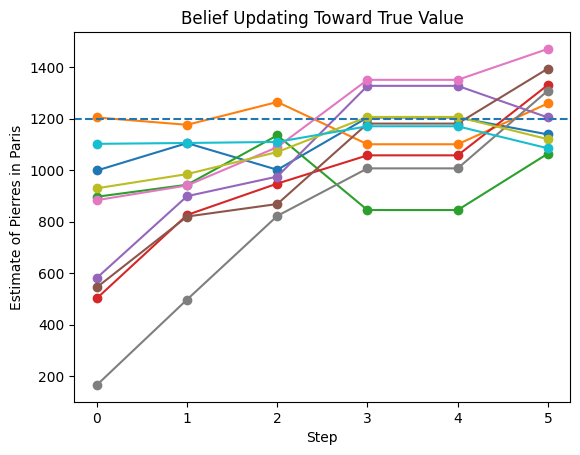

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# 1. Setup
# -----------------------
np.random.seed(42)

TRUE_VALUE = 1200
n_participants = 10

evidence_specs = [
    ("strong_pos", 100),
    ("moderate_pos", 250),
    ("weak_pos", 500),
    ("neutral", 800),
    ("weak_neg", 400)
]

# -----------------------
# 2. Simulation
# -----------------------
data = []

for p in range(n_participants):
    participant_id = f"P{p+1}"
    
    guess = np.random.normal(loc=800, scale=400)
    alpha = np.random.uniform(0.2, 0.7)
    
    data.append([participant_id, 0, "prior", None, guess, guess, alpha])
    
    for step, (etype, noise) in enumerate(evidence_specs, start=1):
        
        if etype == "weak_neg":
            evidence = TRUE_VALUE - np.random.normal(0, noise)
        elif etype == "neutral":
            evidence = guess
        else:
            evidence = np.random.normal(TRUE_VALUE, noise)
        
        guess_before = guess
        guess = guess + alpha * (evidence - guess)
        
        data.append([
            participant_id,
            step,
            etype,
            evidence,
            guess_before,
            guess,
            alpha
        ])

df = pd.DataFrame(data, columns=[
    "participant",
    "step",
    "evidence_type",
    "evidence_value",
    "guess_before",
    "guess_after",
    "alpha"
])

# -----------------------
# 3. Accuracy Metrics
# -----------------------
df["error_after"] = abs(df["guess_after"] - TRUE_VALUE)

# Closest participant at each step
closest_each_step = df.loc[df.groupby("step")["error_after"].idxmin()]

print("\nClosest at each step:")
print(closest_each_step[["step", "participant", "guess_after", "error_after"]])

# -----------------------
# 4. Early vs Late Performance
# -----------------------
early = df[df["step"].isin([1,2])]
early_scores = early.groupby("participant")["error_after"].mean()

final = df[df["step"] == 5]
final_scores = final.set_index("participant")["error_after"]

results = pd.DataFrame({
    "early_error": early_scores,
    "final_error": final_scores
})

results["early_rank"] = results["early_error"].rank()
results["final_rank"] = results["final_error"].rank()

print("\nPerformance comparison:")
print(results.sort_values("final_rank"))

# -----------------------
# 5. Improvement
# -----------------------
start = df[df["step"] == 0].set_index("participant")["error_after"]
end = df[df["step"] == 5].set_index("participant")["error_after"]

improvement = (start - end).sort_values(ascending=False)

print("\nMost improved participants:")
print(improvement)

# -----------------------
# 6. Visualization
# -----------------------
plt.figure()

for p in df["participant"].unique():
    subset = df[df["participant"] == p]
    plt.plot(subset["step"], subset["guess_after"], marker='o')

plt.axhline(TRUE_VALUE, linestyle='--')
plt.xlabel("Step")
plt.ylabel("Estimate of Pierres in Paris")
plt.title("Belief Updating Toward True Value")

plt.show()

Different Version with Alternating Evidence Revealed

In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)

# -----------------------
# 1. Setup
# -----------------------
TRUE_VALUE = 1200
n_participants = 10

# Evidence definitions
evidence_dict = {
    "e1_strong_pos": ("strong_pos", 100),
    "e2_moderate_pos": ("moderate_pos", 250),
    "e3_weak_pos": ("weak_pos", 500),
    "e4_neutral": ("neutral", 800),
    "e5_weak_neg": ("weak_neg", 400)
}

# Two different orders (alternating participants)
order_A = ["e1_strong_pos", "e2_moderate_pos", "e3_weak_pos", "e4_neutral", "e5_weak_neg"]
order_B = ["e3_weak_pos", "e1_strong_pos", "e5_weak_neg", "e2_moderate_pos", "e4_neutral"]

data = []

# -----------------------
# 2. Simulation
# -----------------------
for p in range(n_participants):
    participant_id = f"P{p+1}"
    
    # Alternate order
    if p % 2 == 0:
        evidence_order = order_A
    else:
        evidence_order = order_B
    
    # Some participants ignore negative evidence (first 3 do)
    ignores_negative = True if p < 3 else False
    
    # Initial guess
    guess = np.random.normal(loc=800, scale=400)
    
    # Learning rate
    alpha = np.random.uniform(0.2, 0.7)
    
    # Step 0
    data.append([
        participant_id, 0, "prior", None,
        guess, guess, 0, alpha, ignores_negative
    ])
    
    # Sequential updates
    for step, key in enumerate(evidence_order, start=1):
        etype, noise = evidence_dict[key]
        
        # Generate evidence
        if etype == "weak_neg":
            evidence = TRUE_VALUE - np.random.normal(0, noise)
        elif etype == "neutral":
            evidence = guess
        else:
            evidence = np.random.normal(TRUE_VALUE, noise)
        
        guess_before = guess
        
        # If participant ignores negative evidence
        if ignores_negative and etype == "weak_neg":
            guess_after = guess  # no update
        else:
            guess_after = guess + alpha * (evidence - guess)
        
        delta = guess_after - guess_before
        
        guess = guess_after
        
        data.append([
            participant_id,
            step,
            etype,
            evidence,
            guess_before,
            guess_after,
            delta,
            alpha,
            ignores_negative
        ])

# -----------------------
# 3. Create DataFrame
# -----------------------
df = pd.DataFrame(data, columns=[
    "participant",
    "step",
    "evidence_type",
    "evidence_value",
    "guess_before",
    "guess_after",
    "change",
    "alpha",
    "ignores_negative"
])

# Accuracy
df["error_after"] = abs(df["guess_after"] - TRUE_VALUE)

# -----------------------
# 4. Output Tables
# -----------------------

print("\nFULL RAW RESULTS:")
print(df)

print("\nSTEP-BY-STEP CHANGES:")
print(df[["participant", "step", "evidence_type", "change"]])

# -----------------------
# 5. Compare Orders
# -----------------------

# Identify which order each participant had
df["order"] = df["participant"].apply(lambda x: "A" if int(x[1:]) % 2 == 1 else "B")

final = df[df["step"] == 5]

order_comparison = final.groupby("order")["error_after"].mean()

print("\nORDER COMPARISON (Final Error):")
print(order_comparison)

# -----------------------
# 6. Who handled negative evidence best?
# -----------------------

neg_steps = df[df["evidence_type"] == "weak_neg"]

print("\nREACTION TO NEGATIVE EVIDENCE:")
print(neg_steps[[
    "participant",
    "guess_before",
    "guess_after",
    "change",
    "ignores_negative"
]])


FULL RAW RESULTS:
   participant  step evidence_type  evidence_value  guess_before  guess_after  \
0           P1     0         prior             NaN    998.685661   998.685661   
1           P1     1    strong_pos     1186.173570    998.685661  1104.803250   
2           P1     2  moderate_pos      922.029970   1104.803250  1001.354127   
3           P1     3      weak_pos     1359.451092   1001.354127  1204.035925   
4           P1     4       neutral     1204.035925   1204.035925  1204.035925   
5           P1     5      weak_neg     1088.383483   1204.035925  1204.035925   
6           P2     0         prior             NaN   1204.206114  1204.206114   
7           P2     1      weak_pos      965.262807   1204.206114  1071.822851   
8           P2     2    strong_pos     1254.256004   1071.822851  1172.897438   
9           P2     3      weak_neg     1385.367077   1172.897438  1172.897438   
10          P2     4  moderate_pos     1083.567562   1172.897438  1123.405445   
11       

Version with Twenty Participants, Five Evidences with Random Order


FULL RAW RESULTS (first 20 rows):
   participant  step    evidence_type  evidence_value  guess_before  \
0           P1     0            prior             NaN    989.544333   
1           P1     1  e2_moderate_pos     1542.112531    989.544333   
2           P1     2      e5_weak_neg     1162.151599   1153.127431   
3           P1     3      e3_weak_pos      735.585950   1151.219197   
4           P1     4    e1_strong_pos     1111.476965   1080.907954   
5           P1     5       e4_neutral      870.249216   1093.836090   
6           P2     0            prior             NaN    893.238096   
7           P2     1      e5_weak_neg     1247.197845    893.238096   
8           P2     2       e4_neutral     1217.777461    857.773208   
9           P2     3    e1_strong_pos     1157.220709    857.773208   
10          P2     4  e2_moderate_pos     1067.045647    917.779308   
11          P2     5      e3_weak_pos     1141.262249    938.717280   
12          P3     0            prior     

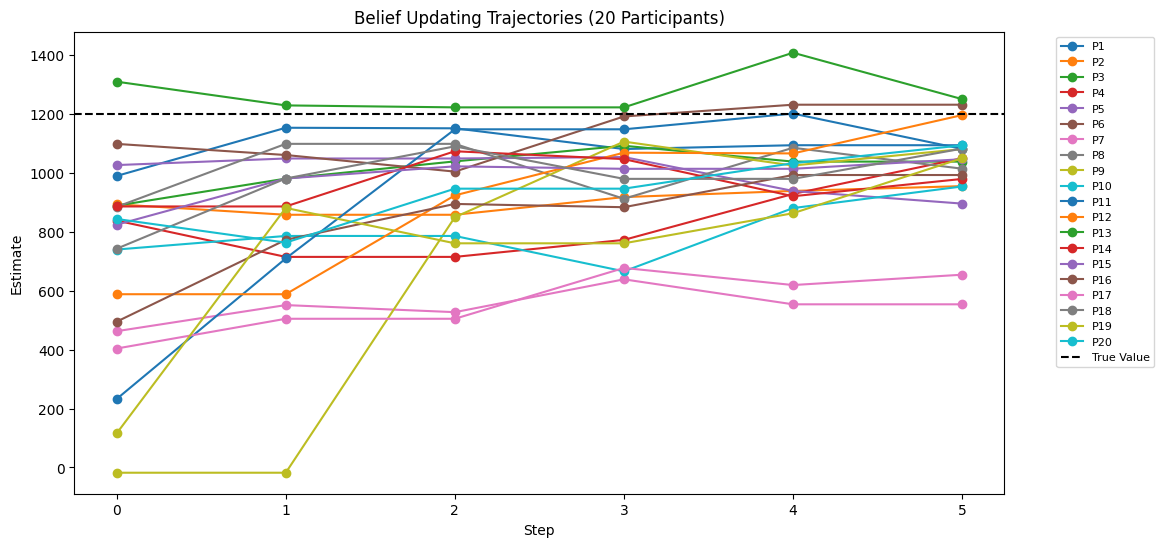

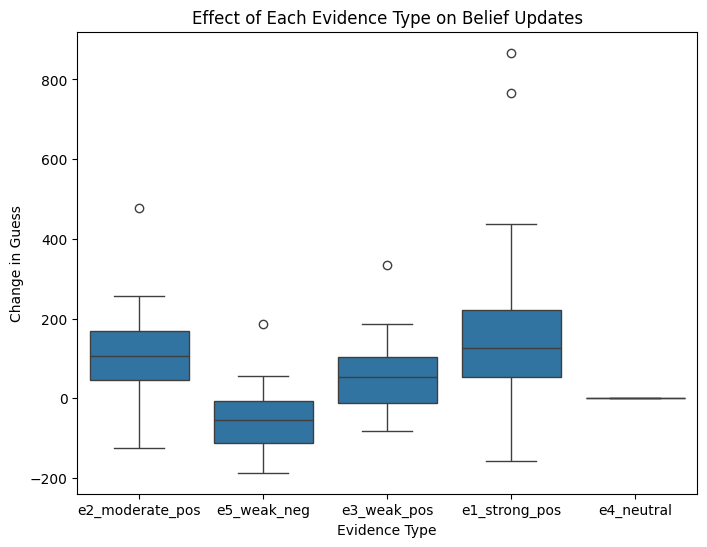

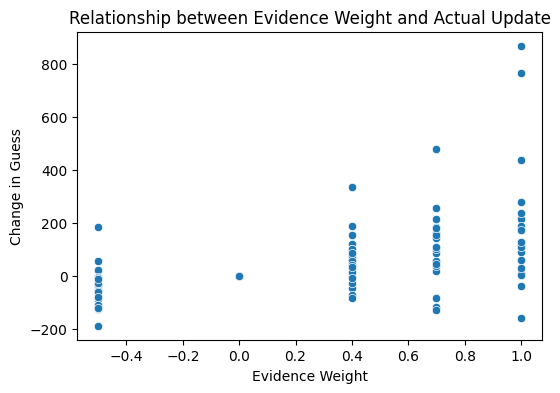

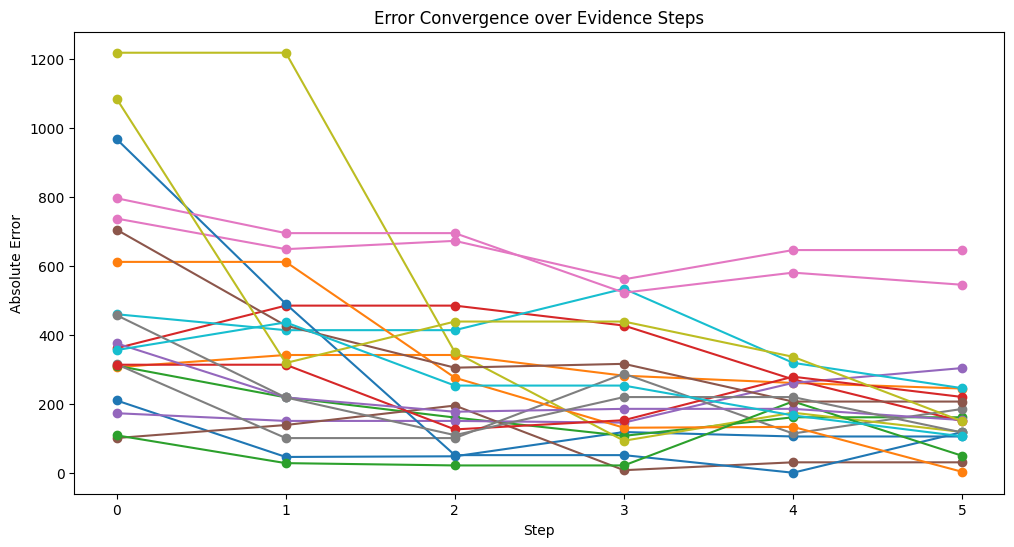

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# -----------------------
# 1. Setup
# -----------------------
TRUE_VALUE = 1200
n_participants = 20

# Evidence definitions with weights (use weight to scale influence)
evidence_dict = {
    "e1_strong_pos": {"noise": 100, "weight": 1.0},
    "e2_moderate_pos": {"noise": 250, "weight": 0.7},
    "e3_weak_pos": {"noise": 500, "weight": 0.4},
    "e4_neutral": {"noise": 800, "weight": 0.0},  # neutral → weight 0
    "e5_weak_neg": {"noise": 400, "weight": -0.5} # negative → can reduce influence
}

# -----------------------
# 2. Simulation
# -----------------------
data = []

for p in range(n_participants):
    participant_id = f"P{p+1}"
    
    # Randomize evidence order for each participant
    evidence_order = np.random.permutation(list(evidence_dict.keys()))
    
    # Some participants ignore negative evidence (first 5 do)
    ignores_negative = True if p < 5 else False
    
    # Initial guess
    guess = np.random.normal(loc=800, scale=400)
    
    # Learning rate
    alpha = np.random.uniform(0.2, 0.7)
    
    # Step 0
    data.append([
        participant_id, 0, "prior", None, guess, guess, 0, alpha, ignores_negative, None
    ])
    
    # Sequential updates
    for step, key in enumerate(evidence_order, start=1):
        etype = key
        noise = evidence_dict[key]["noise"]
        weight = evidence_dict[key]["weight"]
        
        # Generate evidence
        if etype == "weak_neg":
            evidence = TRUE_VALUE - np.random.normal(0, noise)
        elif etype == "neutral":
            evidence = guess
        else:
            evidence = np.random.normal(TRUE_VALUE, noise)
        
        guess_before = guess
        
        # Weighted update
        effective_alpha = alpha * weight
        
        # Ignore negative evidence if participant does
        if ignores_negative and etype == "weak_neg":
            guess_after = guess
        else:
            guess_after = guess + effective_alpha * (evidence - guess)
        
        delta = guess_after - guess_before
        
        guess = guess_after
        
        data.append([
            participant_id,
            step,
            etype,
            evidence,
            guess_before,
            guess_after,
            delta,
            alpha,
            ignores_negative,
            weight
        ])

# -----------------------
# 3. Create DataFrame
# -----------------------
df = pd.DataFrame(data, columns=[
    "participant",
    "step",
    "evidence_type",
    "evidence_value",
    "guess_before",
    "guess_after",
    "change",
    "alpha",
    "ignores_negative",
    "weight"
])

# Accuracy
df["error_after"] = abs(df["guess_after"] - TRUE_VALUE)

# -----------------------
# 4. Raw Results
# -----------------------
print("\nFULL RAW RESULTS (first 20 rows):")
print(df.head(20))

# -----------------------
# 5. Step-by-step change
# -----------------------
step_change = df[["participant","step","evidence_type","change","weight","error_after"]]
print("\nSTEP-BY-STEP CHANGES (first 20 rows):")
print(step_change.head(20))

# -----------------------
# 6. Compare effect of evidence timing
# -----------------------
# Compute correlation between evidence weight and actual impact (delta)
impact_summary = df[df["step"] > 0].groupby("evidence_type")["change"].mean().reset_index()
impact_summary["weight"] = impact_summary["evidence_type"].apply(lambda x: evidence_dict[x]["weight"])

print("\nAVERAGE EFFECT OF EACH PIECE OF EVIDENCE:")
print(impact_summary)

# -----------------------
# 7. Graphs
# -----------------------

# A) Belief trajectories
plt.figure(figsize=(12,6))
for p in df["participant"].unique():
    subset = df[df["participant"] == p]
    plt.plot(subset["step"], subset["guess_after"], marker='o', label=p)
plt.axhline(TRUE_VALUE, linestyle='--', color='black', label='True Value')
plt.xlabel("Step")
plt.ylabel("Estimate")
plt.title("Belief Updating Trajectories (20 Participants)")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left', fontsize=8)
plt.show()

# B) Boxplot: change by evidence type
plt.figure(figsize=(8,6))
sns.boxplot(x="evidence_type", y="change", data=df[df["step"]>0])
plt.xlabel("Evidence Type")
plt.ylabel("Change in Guess")
plt.title("Effect of Each Evidence Type on Belief Updates")
plt.show()

# C) Scatter: weight vs mean change
plt.figure(figsize=(6,4))
sns.scatterplot(x="weight", y="change", data=df[df["step"]>0])
plt.xlabel("Evidence Weight")
plt.ylabel("Change in Guess")
plt.title("Relationship between Evidence Weight and Actual Update")
plt.show()

# D) Error over steps
plt.figure(figsize=(12,6))
for p in df["participant"].unique():
    subset = df[df["participant"] == p]
    plt.plot(subset["step"], subset["error_after"], marker='o', label=p)
plt.xlabel("Step")
plt.ylabel("Absolute Error")
plt.title("Error Convergence over Evidence Steps")
plt.show()


Evidence Effectiveness Ranking:
          evidence_type  percent_improvement  rank
4      population_paris            27.328584     1
1        media_mentions            11.259669     2
2  paris_person_opinion           -38.177442     3
3       popularity_1975           -40.580334     4
0      historical_trend          -138.580971     5


C:\Users\darre\AppData\Local\Temp\ipykernel_26204\827716453.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="evidence_type", y="percent_improvement", data=summary, palette="viridis")


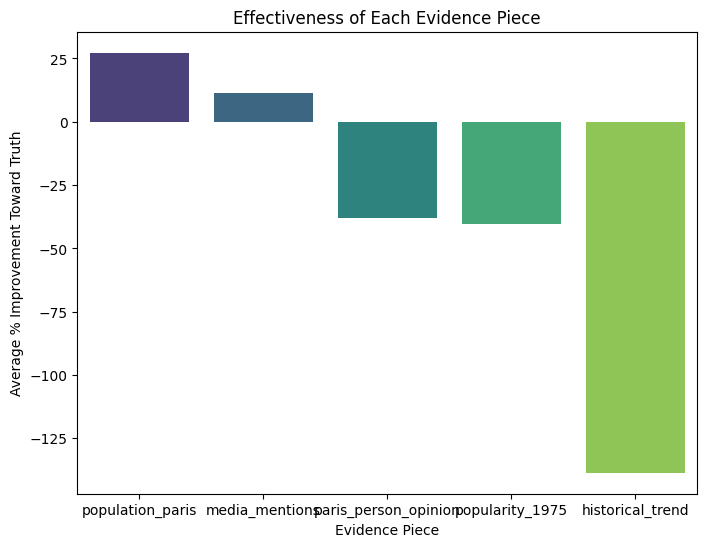

ValueError: Wedge sizes 'x' must be non negative values

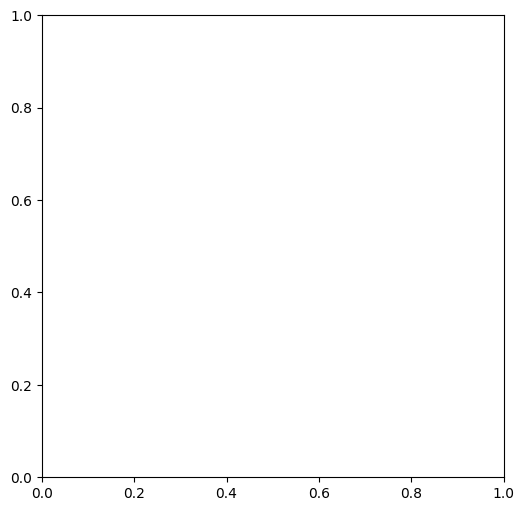

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# -----------------------
# 1. Setup
# -----------------------
TRUE_VALUE = 1200
n_participants = 20

# Evidence definitions
evidence_dict = {
    "population_paris": {"noise": 100},
    "popularity_1975": {"noise": 250},
    "paris_person_opinion": {"noise": 300},
    "historical_trend": {"noise": 400},
    "media_mentions": {"noise": 500}
}

evidence_keys = list(evidence_dict.keys())

# -----------------------
# 2. Simulation
# -----------------------
data = []

for p in range(n_participants):
    participant_id = f"P{p+1}"
    
    # Randomize order
    evidence_order = np.random.permutation(evidence_keys)
    
    # Initial guess (500–5000)
    guess = np.random.uniform(500, 5000)
    
    # Learning rate
    alpha = np.random.uniform(0.2, 0.7)
    
    # Step 0
    data.append([
        participant_id, 0, "prior", None, guess, guess, 0, alpha
    ])
    
    for step, key in enumerate(evidence_order, start=1):
        noise = evidence_dict[key]["noise"]
        
        # Generate evidence
        evidence = np.random.normal(TRUE_VALUE, noise)
        
        guess_before = guess
        # Update
        guess_after = guess + alpha * (evidence - guess)
        
        # Percentage improvement toward truth
        # If previous error = guess_before - TRUE, improvement = how much closer
        prev_error = abs(guess_before - TRUE_VALUE)
        new_error = abs(guess_after - TRUE_VALUE)
        if prev_error == 0:
            perc_improvement = 0
        else:
            perc_improvement = (prev_error - new_error) / prev_error * 100
        
        guess = guess_after
        
        data.append([
            participant_id,
            step,
            key,
            evidence,
            guess_before,
            guess_after,
            perc_improvement,
            alpha
        ])

# -----------------------
# 3. Create DataFrame
# -----------------------
df = pd.DataFrame(data, columns=[
    "participant",
    "step",
    "evidence_type",
    "evidence_value",
    "guess_before",
    "guess_after",
    "percent_improvement",
    "alpha"
])

# -----------------------
# 4. Summarize Evidence Usefulness
# -----------------------
summary = df[df["step"]>0].groupby("evidence_type")["percent_improvement"].mean().reset_index()
summary = summary.sort_values("percent_improvement", ascending=False)
summary["rank"] = range(1, len(summary)+1)

print("\nEvidence Effectiveness Ranking:")
print(summary)

# -----------------------
# 5. Graphs
# -----------------------

# A) Bar chart
plt.figure(figsize=(8,6))
sns.barplot(x="evidence_type", y="percent_improvement", data=summary, palette="viridis")
plt.ylabel("Average % Improvement Toward Truth")
plt.xlabel("Evidence Piece")
plt.title("Effectiveness of Each Evidence Piece")
plt.show()

# B) Pie chart
plt.figure(figsize=(6,6))
plt.pie(summary["percent_improvement"], labels=summary["evidence_type"], autopct='%1.1f%%', startangle=140, colors=sns.color_palette("viridis", len(summary)))
plt.title("Relative Contribution of Each Evidence Piece")
plt.show()

# -----------------------
# 6. Optional: Timing Effect
# -----------------------
# Add position in order
df_positions = df[df["step"]>0].copy()
df_positions["order_position"] = df_positions.groupby("participant").cumcount() + 1

# Average improvement by position
position_summary = df_positions.groupby("order_position")["percent_improvement"].mean().reset_index()
plt.figure(figsize=(6,4))
sns.lineplot(x="order_position", y="percent_improvement", data=position_summary, marker='o')
plt.xlabel("Evidence Position in Sequence")
plt.ylabel("Average % Improvement")
plt.title("Effect of Evidence Position on Belief Updating")
plt.show()


Evidence Effectiveness Ranking:
          evidence_type  percent_improvement  rank
4      population_paris            27.328584     1
1        media_mentions            11.259669     2
2  paris_person_opinion           -38.177442     3
3       popularity_1975           -40.580334     4
0      historical_trend          -138.580971     5


C:\Users\darre\AppData\Local\Temp\ipykernel_26204\827716453.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="evidence_type", y="percent_improvement", data=summary, palette="viridis")


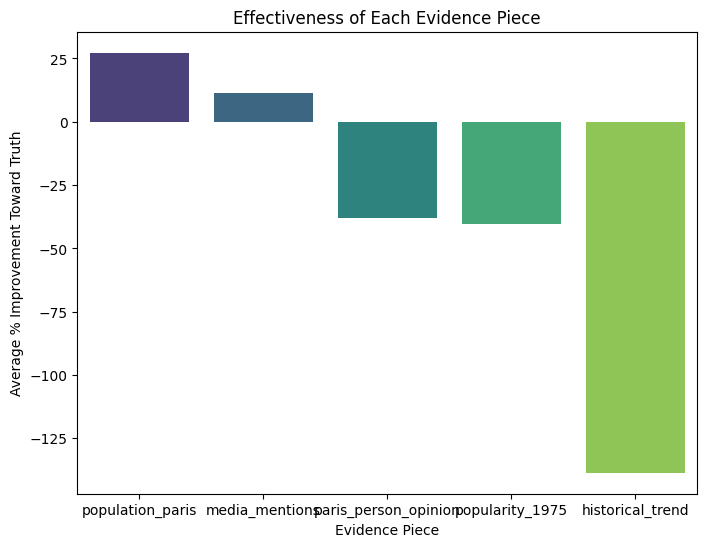

ValueError: Wedge sizes 'x' must be non negative values

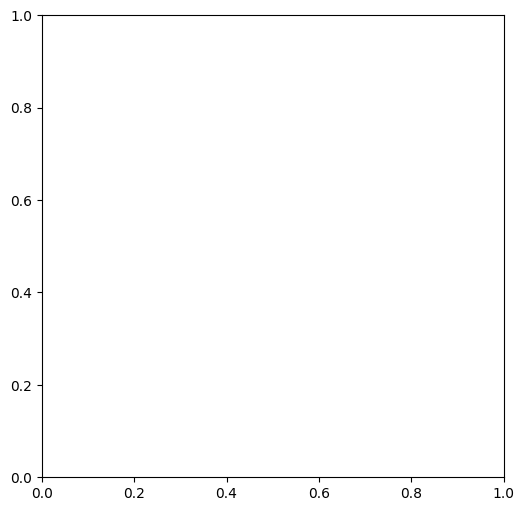

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# -----------------------
# 1. Setup
# -----------------------
TRUE_VALUE = 1200
n_participants = 20

# Evidence definitions
evidence_dict = {
    "population_paris": {"noise": 100},
    "popularity_1975": {"noise": 250},
    "paris_person_opinion": {"noise": 300},
    "historical_trend": {"noise": 400},
    "media_mentions": {"noise": 500}
}

evidence_keys = list(evidence_dict.keys())

# -----------------------
# 2. Simulation
# -----------------------
data = []

for p in range(n_participants):
    participant_id = f"P{p+1}"
    
    # Randomize order
    evidence_order = np.random.permutation(evidence_keys)
    
    # Initial guess (500–5000)
    guess = np.random.uniform(500, 5000)
    
    # Learning rate
    alpha = np.random.uniform(0.2, 0.7)
    
    # Step 0
    data.append([
        participant_id, 0, "prior", None, guess, guess, 0, alpha
    ])
    
    for step, key in enumerate(evidence_order, start=1):
        noise = evidence_dict[key]["noise"]
        
        # Generate evidence
        evidence = np.random.normal(TRUE_VALUE, noise)
        
        guess_before = guess
        # Update
        guess_after = guess + alpha * (evidence - guess)
        
        # Percentage improvement toward truth
        # If previous error = guess_before - TRUE, improvement = how much closer
        prev_error = abs(guess_before - TRUE_VALUE)
        new_error = abs(guess_after - TRUE_VALUE)
        if prev_error == 0:
            perc_improvement = 0
        else:
            perc_improvement = (prev_error - new_error) / prev_error * 100
        
        guess = guess_after
        
        data.append([
            participant_id,
            step,
            key,
            evidence,
            guess_before,
            guess_after,
            perc_improvement,
            alpha
        ])

# -----------------------
# 3. Create DataFrame
# -----------------------
df = pd.DataFrame(data, columns=[
    "participant",
    "step",
    "evidence_type",
    "evidence_value",
    "guess_before",
    "guess_after",
    "percent_improvement",
    "alpha"
])

# -----------------------
# 4. Summarize Evidence Usefulness
# -----------------------
summary = df[df["step"]>0].groupby("evidence_type")["percent_improvement"].mean().reset_index()
summary = summary.sort_values("percent_improvement", ascending=False)
summary["rank"] = range(1, len(summary)+1)

print("\nEvidence Effectiveness Ranking:")
print(summary)

# -----------------------
# 5. Graphs
# -----------------------

# A) Bar chart
plt.figure(figsize=(8,6))
sns.barplot(x="evidence_type", y="percent_improvement", data=summary, palette="viridis")
plt.ylabel("Average % Improvement Toward Truth")
plt.xlabel("Evidence Piece")
plt.title("Effectiveness of Each Evidence Piece")
plt.show()

# B) Pie chart
plt.figure(figsize=(6,6))
plt.pie(summary["percent_improvement"], labels=summary["evidence_type"], autopct='%1.1f%%', startangle=140, colors=sns.color_palette("viridis", len(summary)))
plt.title("Relative Contribution of Each Evidence Piece")
plt.show()

# -----------------------
# 6. Optional: Timing Effect
# -----------------------
# Add position in order
df_positions = df[df["step"]>0].copy()
df_positions["order_position"] = df_positions.groupby("participant").cumcount() + 1

# Average improvement by position
position_summary = df_positions.groupby("order_position")["percent_improvement"].mean().reset_index()
plt.figure(figsize=(6,4))
sns.lineplot(x="order_position", y="percent_improvement", data=position_summary, marker='o')
plt.xlabel("Evidence Position in Sequence")
plt.ylabel("Average % Improvement")
plt.title("Effect of Evidence Position on Belief Updating")
plt.show()


Participant Combined Performance:
   participant  combined_percent_improvement  combined_rank
8          P17                     39.981169            1.0
4          P13                     36.206913            2.0
1          P10                     29.208872            3.0
9          P18                     26.951524            4.0
6          P15                     26.183406            5.0
13          P3                     25.915970            6.0
18          P8                     24.044863            7.0
2          P11                     23.203224            8.0
14          P4                     17.948047            9.0
5          P14                     11.175739           10.0
16          P6                      6.095735           11.0
19          P9                     -3.015618           12.0
0           P1                     -3.630613           13.0
3          P12                    -26.583115           14.0
11          P2                    -52.059847           15.0
15   

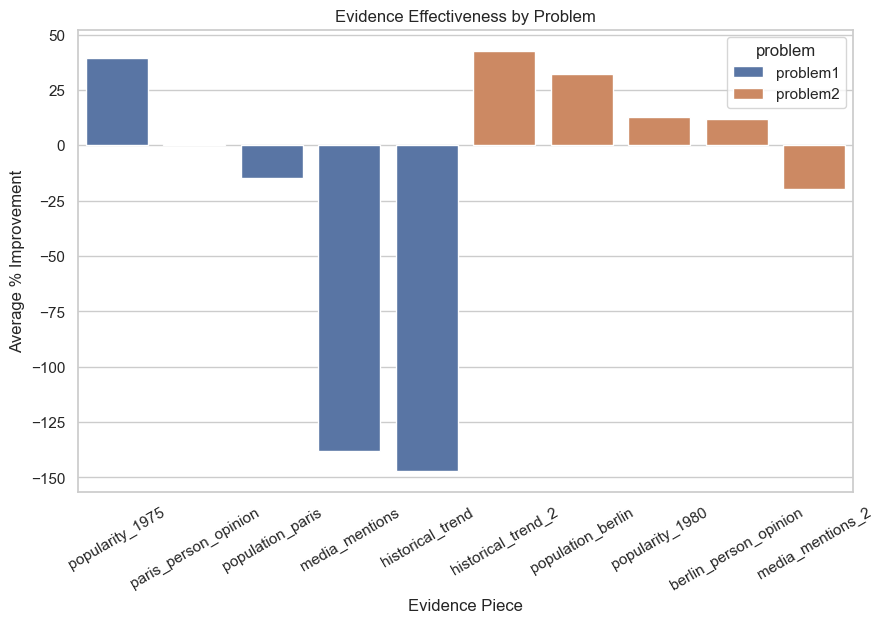

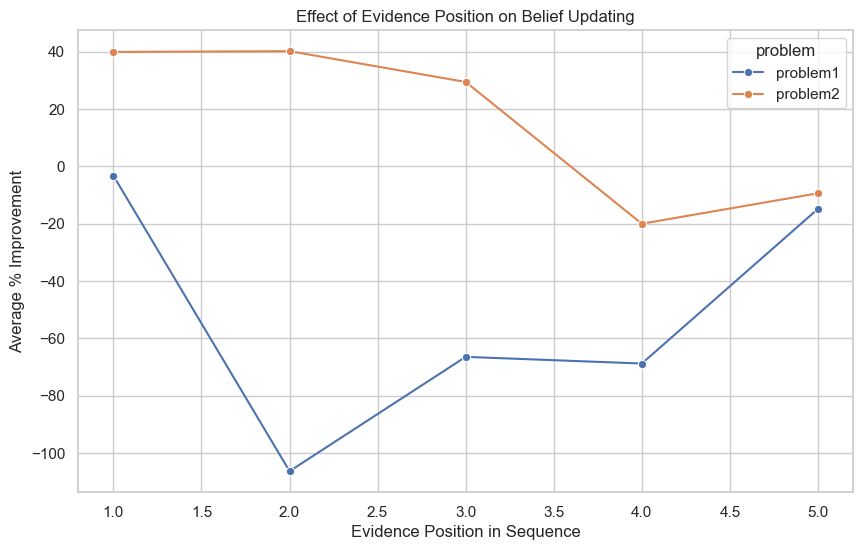

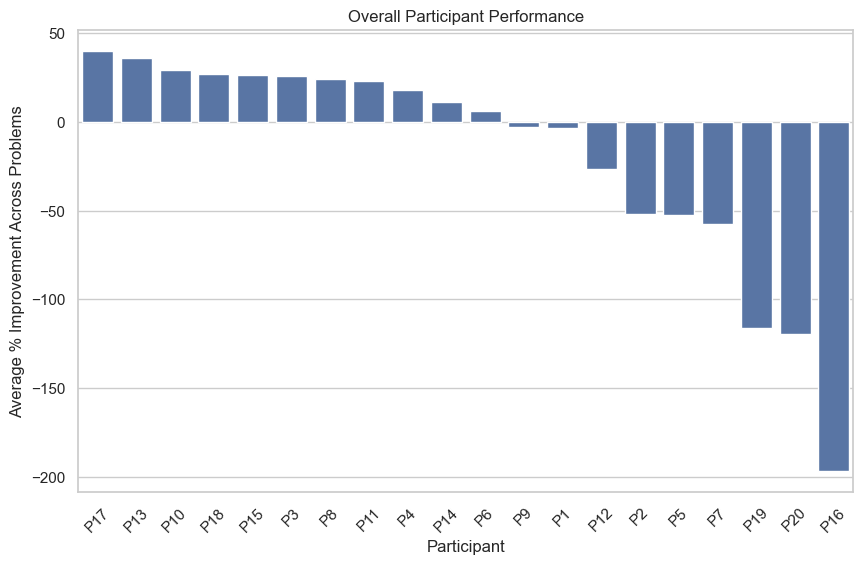

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# -----------------------
# 1. Settings
# -----------------------
TRUE_VALUES = {"problem1": 1200, "problem2": 5000}
n_participants = 20

# Evidence for each problem
evidence_dict = {
    "problem1": ["population_paris", "popularity_1975", "paris_person_opinion", "historical_trend", "media_mentions"],
    "problem2": ["population_berlin", "popularity_1980", "berlin_person_opinion", "historical_trend_2", "media_mentions_2"]
}

noise_dict = {
    "population_paris": 100, "popularity_1975": 250, "paris_person_opinion": 300,
    "historical_trend": 400, "media_mentions": 500,
    "population_berlin": 200, "popularity_1980": 250, "berlin_person_opinion": 300,
    "historical_trend_2": 400, "media_mentions_2": 500
}

# -----------------------
# 2. Participants
# -----------------------
participants = []
for p in range(n_participants):
    participant_id = f"P{p+1}"
    
    # Random percentile for Big Five (0-100)
    big5 = np.random.randint(1,101,5)
    O, C, E, A, N = big5
    
    # Random IQ / Wonderlic (mean 100, sd 15)
    iq = np.random.normal(100, 15)
    
    participants.append({
        "participant": participant_id,
        "O": O, "C": C, "E": E, "A": A, "N": N, "IQ": iq
    })

participants_df = pd.DataFrame(participants)

# -----------------------
# 3. Simulation function
# -----------------------
def simulate_problem(problem_name, true_value, participants_df, alpha_range=(0.2,0.7)):
    data = []
    evidence_list = evidence_dict[problem_name]
    
    for idx, row in participants_df.iterrows():
        participant_id = row['participant']
        alpha = np.random.uniform(*alpha_range)
        guess = np.random.uniform(500, 5000)  # wide initial range
        # Randomized evidence order
        evidence_order = np.random.permutation(evidence_list)
        
        # Step 0
        data.append([participant_id, 0, problem_name, "prior", None, guess, guess, 0, alpha])
        
        # Sequential updates
        for step, key in enumerate(evidence_order, start=1):
            noise = noise_dict[key]
            evidence = np.random.normal(true_value, noise)
            guess_before = guess
            guess_after = guess + alpha*(evidence - guess)
            delta = guess_after - guess_before
            
            # Percentage improvement toward truth
            prev_error = abs(guess_before - true_value)
            new_error = abs(guess_after - true_value)
            if prev_error == 0:
                perc_improvement = 0
            else:
                perc_improvement = (prev_error - new_error) / prev_error * 100
            
            guess = guess_after
            
            data.append([participant_id, step, problem_name, key, evidence, guess_before, guess_after, perc_improvement, alpha])
    
    df = pd.DataFrame(data, columns=["participant","step","problem","evidence_type","evidence_value","guess_before","guess_after","percent_improvement","alpha"])
    return df

# -----------------------
# 4. Run simulation for both problems
# -----------------------
df1 = simulate_problem("problem1", TRUE_VALUES["problem1"], participants_df)
df2 = simulate_problem("problem2", TRUE_VALUES["problem2"], participants_df)

df_all = pd.concat([df1, df2], ignore_index=True)

# -----------------------
# 5. Participant Performance
# -----------------------
# Average percent improvement per problem
performance = df_all[df_all["step"]>0].groupby(["participant","problem"])["percent_improvement"].mean().reset_index()

# Rank participants per problem
performance["rank"] = performance.groupby("problem")["percent_improvement"].rank(ascending=False)

# Combined performance
combined_perf = performance.groupby("participant")["percent_improvement"].mean().reset_index().rename(columns={"percent_improvement":"combined_percent_improvement"})
combined_perf["combined_rank"] = combined_perf["combined_percent_improvement"].rank(ascending=False)

print("\nParticipant Combined Performance:")
print(combined_perf.sort_values("combined_rank"))

# -----------------------
# 6. Evidence Effectiveness per problem
# -----------------------
evidence_summary = df_all[df_all["step"]>0].groupby(["problem","evidence_type"])["percent_improvement"].mean().reset_index()
evidence_summary = evidence_summary.sort_values(["problem","percent_improvement"], ascending=[True,False])
print("\nEvidence Effectiveness Summary:")
print(evidence_summary)

# -----------------------
# 7. Timing Effect
# -----------------------
df_all["order_position"] = df_all.groupby(["participant","problem"]).cumcount()

timing_summary = df_all[df_all["step"]>0].groupby(["problem","order_position"])["percent_improvement"].mean().reset_index()

# -----------------------
# 8. Graphs
# -----------------------
sns.set(style="whitegrid")

# A) Bar chart: average improvement per evidence piece per problem
plt.figure(figsize=(10,6))
sns.barplot(x="evidence_type", y="percent_improvement", hue="problem", data=evidence_summary)
plt.ylabel("Average % Improvement")
plt.xlabel("Evidence Piece")
plt.title("Evidence Effectiveness by Problem")
plt.xticks(rotation=30)
plt.show()

# B) Line chart: effect of evidence position
plt.figure(figsize=(10,6))
sns.lineplot(x="order_position", y="percent_improvement", hue="problem", data=timing_summary, marker='o')
plt.xlabel("Evidence Position in Sequence")
plt.ylabel("Average % Improvement")
plt.title("Effect of Evidence Position on Belief Updating")
plt.show()

# C) Participant performance scatter
plt.figure(figsize=(10,6))
sns.barplot(x="participant", y="combined_percent_improvement", data=combined_perf.sort_values("combined_rank"))
plt.ylabel("Average % Improvement Across Problems")
plt.xlabel("Participant")
plt.title("Overall Participant Performance")
plt.xticks(rotation=45)
plt.show()


Participant Performance Table (Best at End):
   participant   problem  final_guess  rank  initial_guess    O   C   E   A  \
13         P14  problem1  1195.863932   1.0    3340.123817  100  14  95  48   
26          P7  problem2  5016.508642   1.0    3450.751859   62  47  62  51   
11         P12  problem1  1172.799455   2.0    1223.636231    4   2   6  54   
33         P14  problem2  5036.085830   2.0    3163.499325  100  14  95  48   
39         P20  problem2  4913.661198   3.0    4697.278175   41  28   7  73   
5           P6  problem1  1233.525735   3.0    1781.782225   92  60  80  15   
25          P6  problem2  4897.284409   4.0    4825.357537   92  60  80  15   
14         P15  problem1  1139.052225   4.0     609.421849   72  78  87  62   
4           P5  problem1  1264.622835   5.0    1039.394153   76  58  22  89   
28          P9  problem2  5116.936802   5.0    3993.858323   18   4  89  60   
20          P1  problem2  4878.053288   6.0    1628.872373   52  93  15  72   
10    

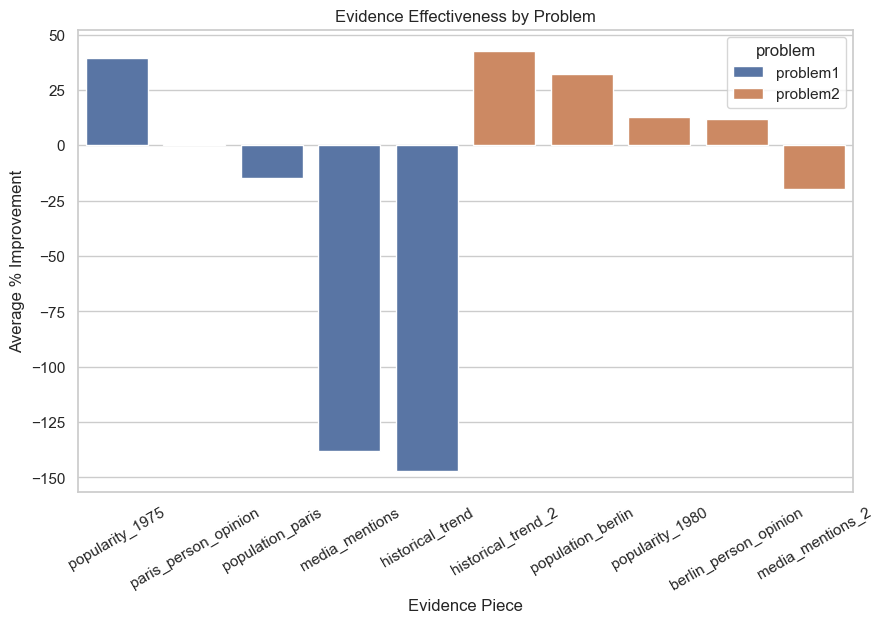

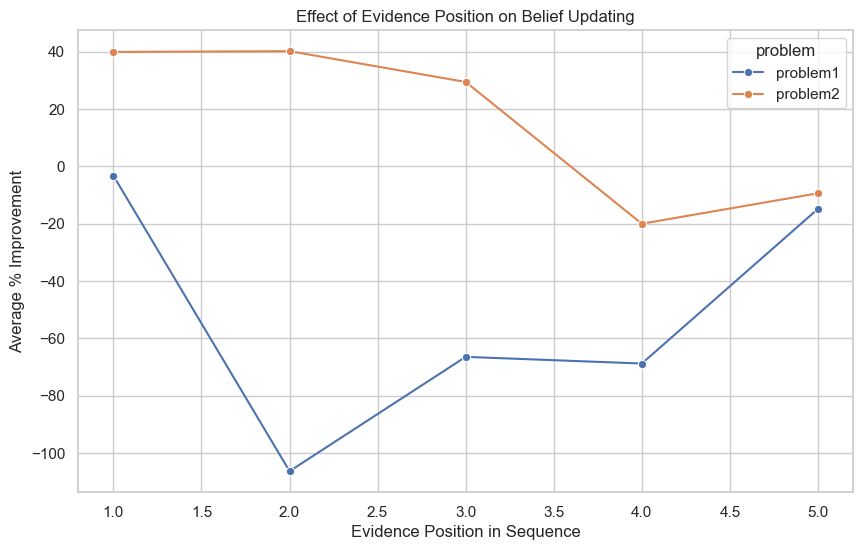

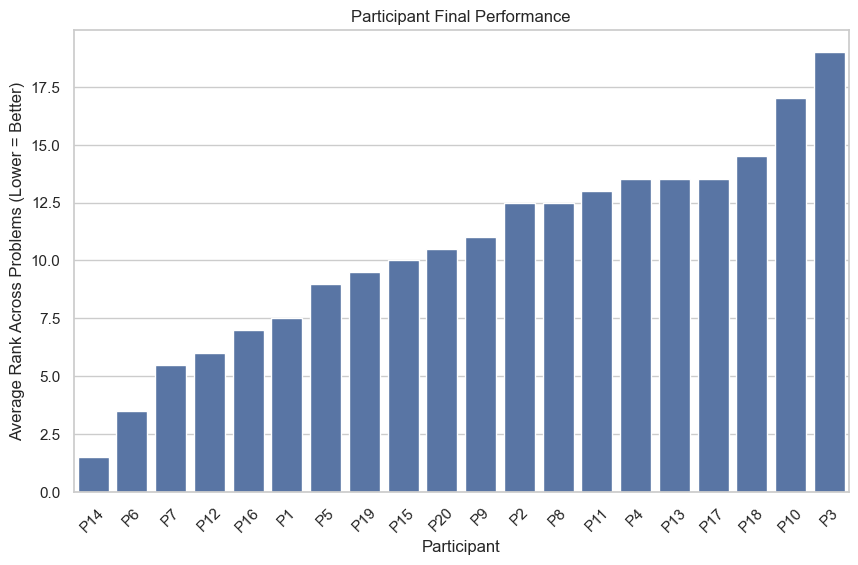

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# -----------------------
# 1. Settings
# -----------------------
TRUE_VALUES = {"problem1": 1200, "problem2": 5000}
n_participants = 20

# Evidence for each problem
evidence_dict = {
    "problem1": ["population_paris", "popularity_1975", "paris_person_opinion", "historical_trend", "media_mentions"],
    "problem2": ["population_berlin", "popularity_1980", "berlin_person_opinion", "historical_trend_2", "media_mentions_2"]
}

noise_dict = {
    "population_paris": 100, "popularity_1975": 250, "paris_person_opinion": 300,
    "historical_trend": 400, "media_mentions": 500,
    "population_berlin": 200, "popularity_1980": 250, "berlin_person_opinion": 300,
    "historical_trend_2": 400, "media_mentions_2": 500
}

# -----------------------
# 2. Participants
# -----------------------
participants = []
for p in range(n_participants):
    participant_id = f"P{p+1}"
    
    # Big Five percentiles (O,C,E,A,N)
    big5 = np.random.randint(1,101,5)
    O, C, E, A, N = big5
    
    # IQ/Wonderlic
    iq = np.random.normal(100, 15)
    
    participants.append({
        "participant": participant_id,
        "O": O, "C": C, "E": E, "A": A, "N": N,
        "IQ": iq
    })

participants_df = pd.DataFrame(participants)

# -----------------------
# 3. Simulation function
# -----------------------
def simulate_problem(problem_name, true_value, participants_df, alpha_range=(0.2,0.7)):
    data = []
    evidence_list = evidence_dict[problem_name]
    
    for idx, row in participants_df.iterrows():
        participant_id = row['participant']
        alpha = np.random.uniform(*alpha_range)
        guess = np.random.uniform(500, 5000)
        evidence_order = np.random.permutation(evidence_list)
        
        initial_guess = guess  # store for table
        
        # Step 0
        data.append([participant_id, 0, problem_name, "prior", None, guess, guess, 0, alpha])
        
        for step, key in enumerate(evidence_order, start=1):
            noise = noise_dict[key]
            evidence = np.random.normal(true_value, noise)
            
            guess_before = guess
            guess_after = guess + alpha*(evidence - guess)
            
            prev_error = abs(guess_before - true_value)
            new_error = abs(guess_after - true_value)
            if prev_error == 0:
                perc_improvement = 0
            else:
                perc_improvement = (prev_error - new_error) / prev_error * 100
            
            guess = guess_after
            
            data.append([participant_id, step, problem_name, key, evidence, guess_before, guess_after, perc_improvement, alpha])
    
    df = pd.DataFrame(data, columns=["participant","step","problem","evidence_type","evidence_value","guess_before","guess_after","percent_improvement","alpha"])
    return df

# -----------------------
# 4. Run simulation
# -----------------------
df1 = simulate_problem("problem1", TRUE_VALUES["problem1"], participants_df)
df2 = simulate_problem("problem2", TRUE_VALUES["problem2"], participants_df)
df_all = pd.concat([df1, df2], ignore_index=True)

# -----------------------
# 5. Participant performance by final guess
# -----------------------
final_guesses = df_all[df_all["step"]>0].groupby(["participant","problem"]).tail(1)
final_guesses["error"] = abs(final_guesses["guess_after"] - final_guesses["evidence_value"].map(lambda x: TRUE_VALUES.get(final_guesses["problem"].iloc[0], 0)))  # note we will fix to TRUE_VALUES per problem

# Corrected error calculation
final_guesses["error"] = final_guesses.apply(lambda row: abs(row["guess_after"] - TRUE_VALUES[row["problem"]]), axis=1)

# Rank participants per problem by final closeness
final_guesses["rank"] = final_guesses.groupby("problem")["error"].rank(method="min")

# Combined rank by averaging rank across problems
combined_rank = final_guesses.groupby("participant")["rank"].mean().reset_index()
combined_rank = combined_rank.sort_values("rank")

# Merge participant info and first guess / last guess
first_guesses = df_all[df_all["step"]==0][["participant","problem","guess_after"]].rename(columns={"guess_after":"initial_guess"})
final_guesses_table = final_guesses[["participant","problem","guess_after","rank"]].rename(columns={"guess_after":"final_guess"})
performance_table = pd.merge(final_guesses_table, first_guesses, on=["participant","problem"])
performance_table = pd.merge(performance_table, participants_df, on="participant")
performance_table = performance_table.sort_values(["rank"])

print("\nParticipant Performance Table (Best at End):")
print(performance_table)

# -----------------------
# 6. Evidence effectiveness per problem
# -----------------------
evidence_summary = df_all[df_all["step"]>0].groupby(["problem","evidence_type"])["percent_improvement"].mean().reset_index()
evidence_summary = evidence_summary.sort_values(["problem","percent_improvement"], ascending=[True,False])
print("\nEvidence Effectiveness Summary:")
print(evidence_summary)

# -----------------------
# 7. Timing effect
# -----------------------
df_all["order_position"] = df_all.groupby(["participant","problem"]).cumcount()
timing_summary = df_all[df_all["step"]>0].groupby(["problem","order_position"])["percent_improvement"].mean().reset_index()

# -----------------------
# 8. Graphs
# -----------------------
sns.set(style="whitegrid")

# Bar chart: average improvement per evidence piece per problem
plt.figure(figsize=(10,6))
sns.barplot(x="evidence_type", y="percent_improvement", hue="problem", data=evidence_summary)
plt.ylabel("Average % Improvement")
plt.xlabel("Evidence Piece")
plt.title("Evidence Effectiveness by Problem")
plt.xticks(rotation=30)
plt.show()

# Line chart: effect of evidence position
plt.figure(figsize=(10,6))
sns.lineplot(x="order_position", y="percent_improvement", hue="problem", data=timing_summary, marker='o')
plt.xlabel("Evidence Position in Sequence")
plt.ylabel("Average % Improvement")
plt.title("Effect of Evidence Position on Belief Updating")
plt.show()

# Bar chart: participant performance by combined rank
plt.figure(figsize=(10,6))
sns.barplot(x="participant", y="rank", data=combined_rank)
plt.ylabel("Average Rank Across Problems (Lower = Better)")
plt.xlabel("Participant")
plt.title("Participant Final Performance")
plt.xticks(rotation=45)
plt.show()


Participant Metrics Table:
   participant    O   C   E   A    N          IQ  avg_final_rank  \
0           P1   52  93  15  72   61   82.032904             7.5   
1           P2   87  75  75  88  100  132.124876            12.5   
2           P3   24   3  22  53    2  103.496429            19.0   
3           P4    2  64  60  21   33  101.769919            13.5   
4           P5   76  58  22  89   49   63.413413             9.0   
5           P6   92  60  80  15   62  109.051618             3.5   
6           P7   62  47  62  51   55   99.633172             5.5   
7           P8   51   7  21  73   39  105.333270            12.5   
8           P9   18   4  89  60   14   90.996192            11.0   
9          P10   53   2  84  92   60  114.211597            17.0   
10         P11   71  44   8  47   35   96.558243            13.0   
11         P12    4   2   6  54    4  105.840234             6.0   
12         P13   54  93  63  18   90   67.324986            13.5   
13         P14  100 

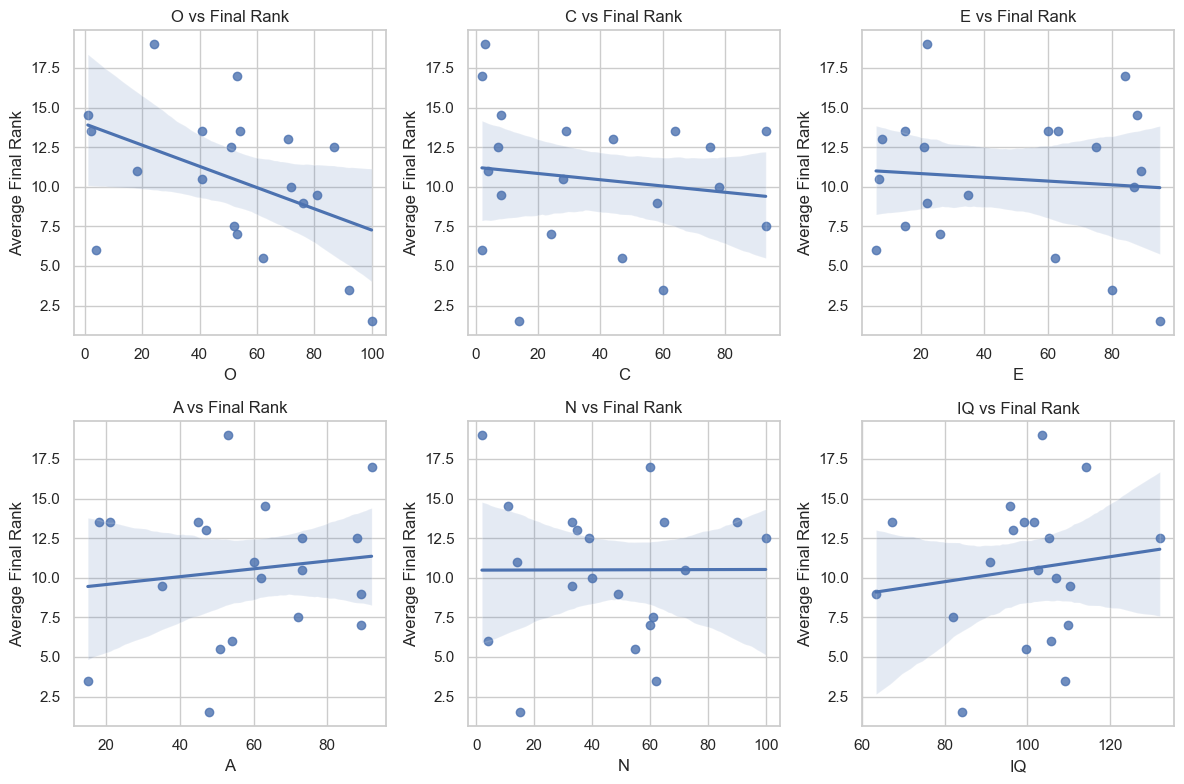

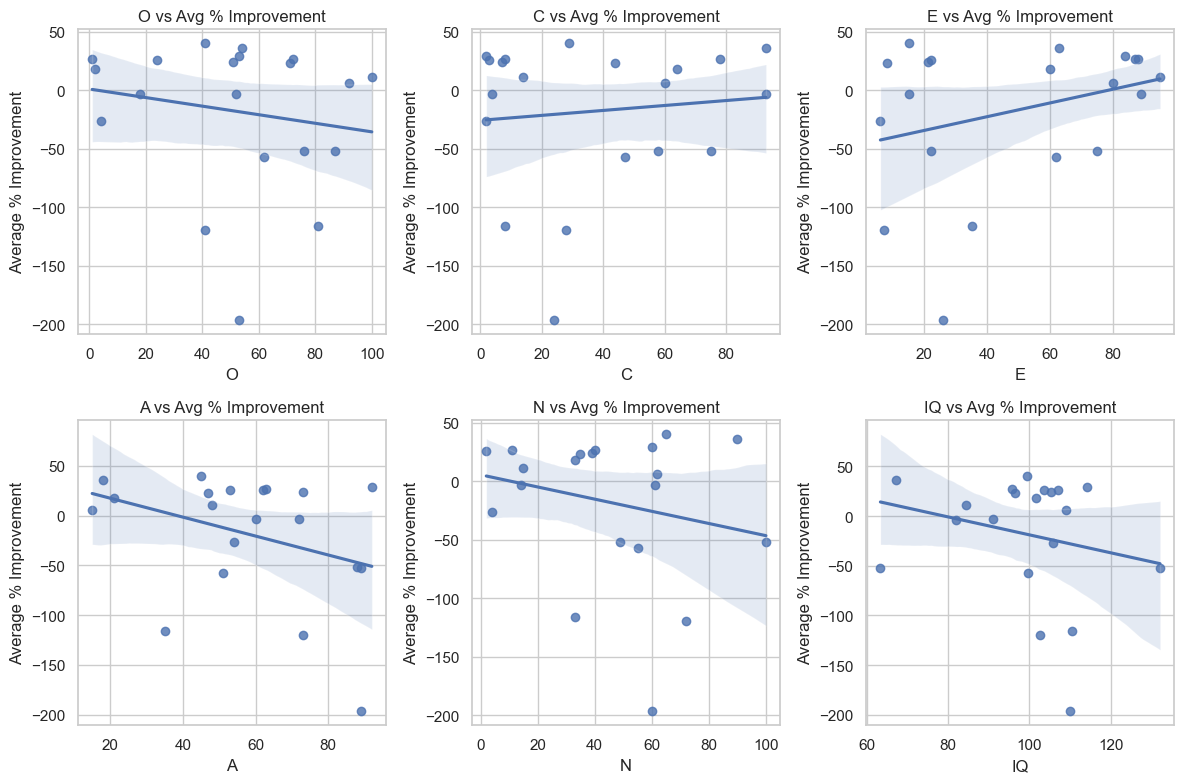

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------
# 1. Compute participant metrics
# -----------------------
# Final rank: average rank across problems
final_ranks = combined_rank.copy()

# Compute total % improvement per participant across all steps
improvement_df = df_all[df_all["step"]>0].groupby("participant")["percent_improvement"].mean().reset_index()
improvement_df = improvement_df.rename(columns={"percent_improvement":"avg_percent_improvement"})

# Merge with participant traits and IQ
participant_metrics = pd.merge(participants_df, final_ranks, on="participant")
participant_metrics = pd.merge(participant_metrics, improvement_df, on="participant")

# Rename columns for clarity
participant_metrics = participant_metrics.rename(columns={"rank":"avg_final_rank"})

print("\nParticipant Metrics Table:")
print(participant_metrics)

# -----------------------
# 2. Correlations
# -----------------------
traits = ["O","C","E","A","N","IQ"]
correlations = participant_metrics[traits + ["avg_final_rank","avg_percent_improvement"]].corr()

print("\nCorrelation Matrix:")
print(correlations[["avg_final_rank","avg_percent_improvement"]])

# -----------------------
# 3. Scatter plots: trait vs final rank
# -----------------------
sns.set(style="whitegrid")
plt.figure(figsize=(12,8))

for i, trait in enumerate(traits, start=1):
    plt.subplot(2,3,i)
    sns.regplot(x=trait, y="avg_final_rank", data=participant_metrics)
    plt.xlabel(trait)
    plt.ylabel("Average Final Rank")
    plt.title(f"{trait} vs Final Rank")

plt.tight_layout()
plt.show()

# -----------------------
# 4. Scatter plots: trait vs average improvement
# -----------------------
plt.figure(figsize=(12,8))

for i, trait in enumerate(traits, start=1):
    plt.subplot(2,3,i)
    sns.regplot(x=trait, y="avg_percent_improvement", data=participant_metrics)
    plt.xlabel(trait)
    plt.ylabel("Average % Improvement")
    plt.title(f"{trait} vs Avg % Improvement")

plt.tight_layout()
plt.show()


Big vs Little Updaters Summary:
   participant  avg_percent_improvement  avg_final_error   updater_group
16         P17                39.981169       301.789468     big_updater
12         P13                36.206913       301.802536     big_updater
9          P10                29.208872       494.062535     big_updater
17         P18                26.951524       401.291962     big_updater
14         P15                26.183406       309.988978     big_updater
2           P3                25.915970       728.588044     big_updater
7           P8                24.044863       421.994962     big_updater
10         P11                23.203224       654.678706     big_updater
3           P4                17.948047       267.690831     big_updater
13         P14                11.175739        20.110949     big_updater
5           P6                 6.095735        68.120663  little_updater
8           P9                -3.015618       242.111102  little_updater
0           P1    

C:\Users\darre\AppData\Local\Temp\ipykernel_26204\723951528.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quintile_summary[trait] = participant_metrics.groupby(f"{trait}_quintile")["avg_final_error"].mean().reset_index().rename(columns={"avg_final_error":"avg_error"})
C:\Users\darre\AppData\Local\Temp\ipykernel_26204\723951528.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quintile_summary[trait] = participant_metrics.groupby(f"{trait}_quintile")["avg_final_error"].mean().reset_index().rename(columns={"avg_final_error":"avg_error"})
C:\Users\darre\AppData\Local\Temp\ipykernel_26204\723951528.py:7

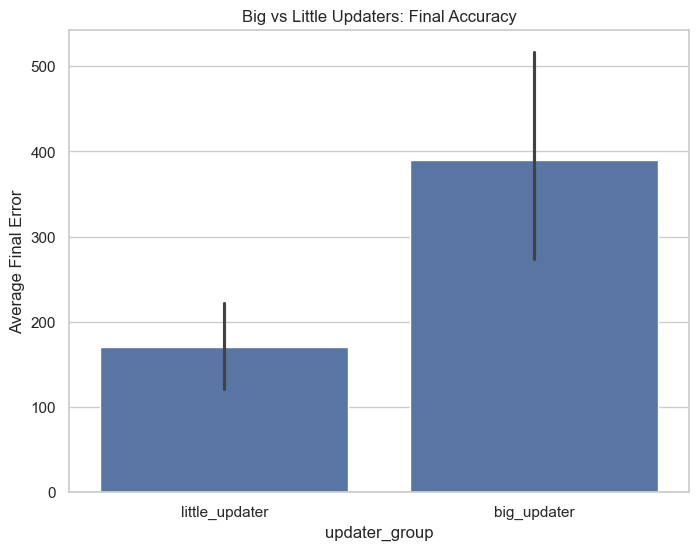

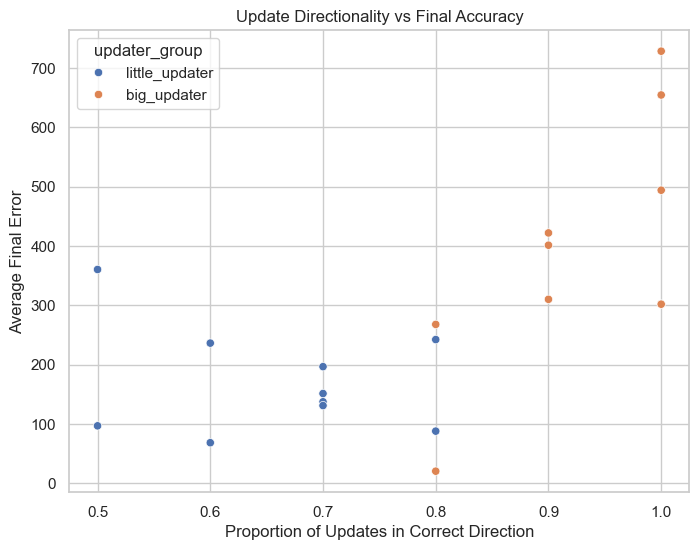

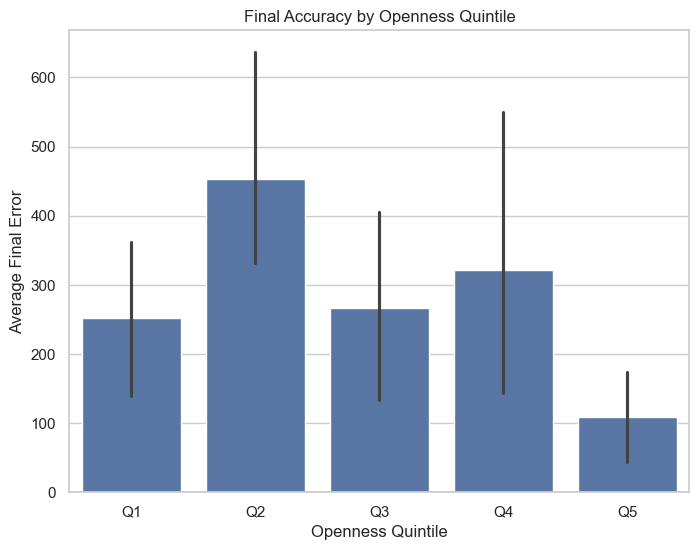

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------
# 1. Compute participant metrics
# -----------------------
# Final error: absolute difference from truth at final guess
final_guesses_df = df_all[df_all["step"]>0].groupby(["participant","problem"]).tail(1)
final_guesses_df["final_error"] = final_guesses_df.apply(lambda row: abs(row["guess_after"] - TRUE_VALUES[row["problem"]]), axis=1)

# Average error across problems
avg_error = final_guesses_df.groupby("participant")["final_error"].mean().reset_index().rename(columns={"final_error":"avg_final_error"})

# Average % improvement per participant
avg_improvement = df_all[df_all["step"]>0].groupby("participant")["percent_improvement"].mean().reset_index().rename(columns={"percent_improvement":"avg_percent_improvement"})

# Merge participant info
participant_metrics = participants_df.copy()
participant_metrics = participant_metrics.merge(avg_error, on="participant")
participant_metrics = participant_metrics.merge(avg_improvement, on="participant")

# -----------------------
# 2. Big vs little updaters
# -----------------------
# Split top 50% vs bottom 50% by avg_percent_improvement
median_update = participant_metrics["avg_percent_improvement"].median()
participant_metrics["updater_group"] = participant_metrics["avg_percent_improvement"].apply(lambda x: "big_updater" if x >= median_update else "little_updater")

print("\nBig vs Little Updaters Summary:")
print(participant_metrics[["participant","avg_percent_improvement","avg_final_error","updater_group"]].sort_values("avg_percent_improvement", ascending=False))

# Compare average final error between groups
group_comparison = participant_metrics.groupby("updater_group")["avg_final_error"].mean().reset_index()
print("\nAverage final error by updater group:")
print(group_comparison)

# -----------------------
# 3. Correct direction update speed
# -----------------------
# Stepwise: check if update moves guess closer to truth
df_all["correct_direction"] = df_all.apply(
    lambda row: 1 if ((row["guess_after"] - TRUE_VALUES[row["problem"]])**2 < (row["guess_before"] - TRUE_VALUES[row["problem"]])**2) else 0, axis=1
)
direction_summary = df_all[df_all["step"]>0].groupby("participant")["correct_direction"].mean().reset_index().rename(columns={"correct_direction":"prop_correct_direction"})
participant_metrics = participant_metrics.merge(direction_summary, on="participant")

# -----------------------
# 4. Trait combinations vs final success
# -----------------------
# Correlations between traits/IQ and final error
traits = ["O","C","E","A","N","IQ"]
correlations = participant_metrics[traits + ["avg_final_error","avg_percent_improvement"]].corr()
print("\nTrait and IQ correlations with final error / improvement:")
print(correlations[["avg_final_error","avg_percent_improvement"]])

# -----------------------
# 5. Quintile comparisons
# -----------------------
# Function to assign quintiles (0-20,20-40,40-60,60-80,80-100)
def quintile_bins(series):
    return pd.qcut(series, q=5, labels=["Q1","Q2","Q3","Q4","Q5"])

for trait in traits:
    participant_metrics[f"{trait}_quintile"] = quintile_bins(participant_metrics[trait])

# Average final error by quintile for each trait
quintile_summary = {}
for trait in traits:
    quintile_summary[trait] = participant_metrics.groupby(f"{trait}_quintile")["avg_final_error"].mean().reset_index().rename(columns={"avg_final_error":"avg_error"})
    print(f"\nAverage final error by {trait} quintile:")
    print(quintile_summary[trait])

# -----------------------
# 6. Top 4 vs next 4 comparison for each trait/IQ
# -----------------------
top_vs_next = {}
for trait in traits:
    sorted_df = participant_metrics.sort_values(trait, ascending=False)
    top4 = sorted_df.head(4)["avg_final_error"].mean()
    next4 = sorted_df.iloc[4:8]["avg_final_error"].mean()
    top_vs_next[trait] = {"top4_avg_error":top4, "next4_avg_error":next4}

print("\nTop 4 vs Next 4 by Trait/IQ (avg final error):")
for trait, vals in top_vs_next.items():
    print(f"{trait}: Top4={vals['top4_avg_error']:.2f}, Next4={vals['next4_avg_error']:.2f}")

# -----------------------
# 7. Graphs
# -----------------------
sns.set(style="whitegrid")

# A) Big vs little updaters final error
plt.figure(figsize=(8,6))
sns.barplot(x="updater_group", y="avg_final_error", data=participant_metrics)
plt.ylabel("Average Final Error")
plt.title("Big vs Little Updaters: Final Accuracy")
plt.show()

# B) Prop correct direction vs avg final error
plt.figure(figsize=(8,6))
sns.scatterplot(x="prop_correct_direction", y="avg_final_error", hue="updater_group", data=participant_metrics)
plt.xlabel("Proportion of Updates in Correct Direction")
plt.ylabel("Average Final Error")
plt.title("Update Directionality vs Final Accuracy")
plt.show()

# C) Example: O quintiles vs final error
plt.figure(figsize=(8,6))
sns.barplot(x="O_quintile", y="avg_final_error", data=participant_metrics, order=["Q1","Q2","Q3","Q4","Q5"])
plt.xlabel("Openness Quintile")
plt.ylabel("Average Final Error")
plt.title("Final Accuracy by Openness Quintile")
plt.show()

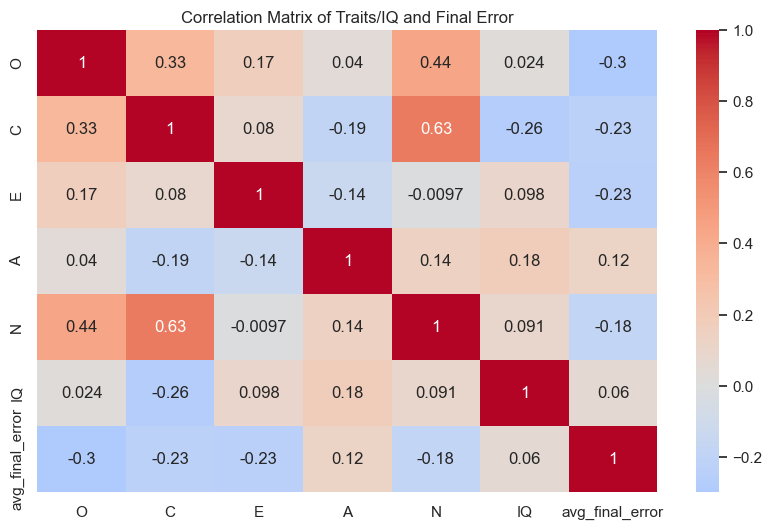

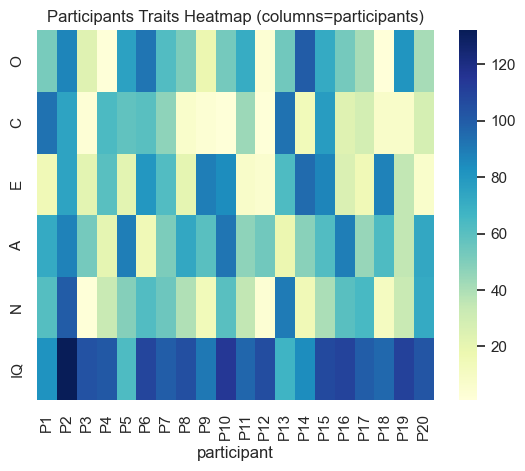


Regression Results:
                             OLS Regression Results                            
Dep. Variable:        avg_final_error   R-squared:                       0.150
Model:                            OLS   Adj. R-squared:                 -0.243
Method:                 Least Squares   F-statistic:                    0.3813
Date:                Thu, 26 Mar 2026   Prob (F-statistic):              0.878
Time:                        01:32:24   Log-Likelihood:                -131.15
No. Observations:                  20   AIC:                             276.3
Df Residuals:                      13   BIC:                             283.3
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        331.0649    366.5

KeyError: "['error'] not in index"

In [10]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# -----------------------
# 1. Heatmap of traits/IQ vs final error
# -----------------------
traits_iq = ["O","C","E","A","N","IQ"]
heatmap_df = participant_metrics.set_index("participant")[traits_iq + ["avg_final_error"]].sort_values("avg_final_error")

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_df.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Traits/IQ and Final Error")
plt.show()

# Heatmap showing participants (rows) vs traits/IQ (columns) with final error as value
participant_values = participant_metrics.set_index("participant")[traits_iq]
errors = participant_metrics.set_index("participant")["avg_final_error"]
sns.heatmap(participant_values.T, annot=False, cmap="YlGnBu")
plt.title("Participants Traits Heatmap (columns=participants)")
plt.show()

# -----------------------
# 2. Regression: final error ~ OCEAN + IQ
# -----------------------
X = participant_metrics[traits_iq]
X = sm.add_constant(X)  # adds intercept
y = participant_metrics["avg_final_error"]

model = sm.OLS(y, X).fit()
print("\nRegression Results:\n", model.summary())

# -----------------------
# Optional: regression with interaction O*C*IQ
# -----------------------
participant_metrics["O_C_IQ"] = participant_metrics["O"]*participant_metrics["C"]*participant_metrics["IQ"]
X_int = participant_metrics[traits_iq + ["O_C_IQ"]]
X_int = sm.add_constant(X_int)
model_int = sm.OLS(y, X_int).fit()
print("\nRegression with O*C*IQ interaction:\n", model_int.summary())

# -----------------------
# 3. Evidence order analysis
# -----------------------
# Map evidence to “helpful/harmful”
helpful_evidence = {
    "problem1": ["popularity_1975"],
    "problem2": ["historical_trend_2","population_berlin","popularity_1980","berlin_person_opinion"]
}

# Record order of helpful evidence per participant/problem
order_positions = []
for p in participant_metrics["participant"]:
    for prob in ["problem1","problem2"]:
        df_p = df_all[(df_all["participant"]==p) & (df_all["problem"]==prob)]
        df_p = df_p[df_p["step"]>0]  # only evidence updates
        for e in helpful_evidence[prob]:
            pos = df_p[df_p["evidence_type"]==e]["step"].values[0]  # step in sequence
            order_positions.append({"participant":p, "problem":prob, "evidence":e, "position":pos})

order_df = pd.DataFrame(order_positions)

# Merge with final error
final_error_df = final_guesses_df[["participant","problem","error"]].rename(columns={"error":"final_error"})
order_df = order_df.merge(final_error_df, on=["participant","problem"])

# Compare final error by early vs late exposure
plt.figure(figsize=(10,5))
sns.boxplot(x="position", y="final_error", data=order_df)
plt.xlabel("Order Position of Helpful Evidence")
plt.ylabel("Final Error")
plt.title("Effect of Early vs Late Helpful Evidence on Final Accuracy")
plt.show()

# Compute correlation between helpful evidence position and final error
corrs = order_df.groupby("evidence").apply(lambda x: np.corrcoef(x["position"], x["final_error"])[0,1])
print("\nCorrelation of helpful evidence position with final error:")
print(corrs)

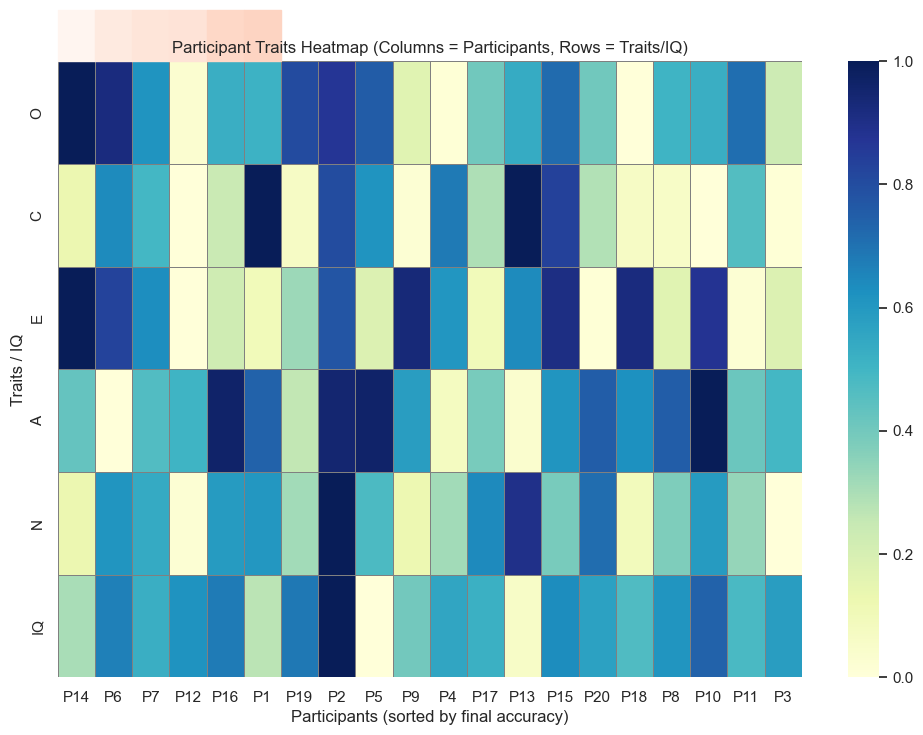

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Traits + IQ
traits_iq = ["O","C","E","A","N","IQ"]

# Sort participants by final performance (best = lowest error)
heatmap_data = participant_metrics.sort_values("avg_final_error").set_index("participant")[traits_iq]

# Normalize traits for heatmap visualization
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

# Add final error as an additional row for coloring (optional)
final_error = participant_metrics.set_index("participant").loc[heatmap_data.index]["avg_final_error"]
# We can scale it for overlay
final_error_scaled = (final_error - final_error.min()) / (final_error.max() - final_error.min())

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(heatmap_norm.T, cmap="YlGnBu", cbar=True, linewidths=0.5, linecolor='gray', annot=False)
plt.title("Participant Traits Heatmap (Columns = Participants, Rows = Traits/IQ)")

# Overlay final error as colored bar on top
for i, col in enumerate(heatmap_norm.columns):
    plt.gca().add_patch(plt.Rectangle((i, -0.5), 1, 0.5, color=plt.cm.Reds(final_error_scaled.iloc[i]), clip_on=False))

plt.ylabel("Traits / IQ")
plt.xlabel("Participants (sorted by final accuracy)")
plt.show()

In [15]:
import itertools
import numpy as np
import pandas as pd
from random import shuffle

# ---------------------------
# Problem 2: define evidence and effectiveness
# ---------------------------
participants = ["P"+str(i) for i in range(1,21)]
TRUE_VALUE2 = 1200

evidence_pieces2 = [
    "historical_trend_2",
    "population_berlin",
    "popularity_1980",
    "berlin_person_opinion",
    "media_mentions_2"
]

evidence_effectiveness2 = {
    "historical_trend_2": 42.70,
    "population_berlin": 32.36,
    "popularity_1980": 12.87,
    "berlin_person_opinion": 11.74,
    "media_mentions_2": -19.79
}

# ---------------------------
# Participant guess update function
# ---------------------------
def update_guess2(guess, evidence):
    effect = evidence_effectiveness2[evidence]/100
    return guess + effect*(TRUE_VALUE2 - guess)

# ---------------------------
# 1. Simulation-based (all permutations)
# ---------------------------
all_perms2 = list(itertools.permutations(evidence_pieces2))
sim_results2 = []

for perm in all_perms2:
    final_errors = []
    for p in participants:
        guess = np.random.randint(500,5000)
        for e in perm:
            guess = update_guess2(guess, e)
        final_errors.append(abs(TRUE_VALUE2 - guess))
    sim_results2.append({"sequence": perm, "avg_final_error": np.mean(final_errors)})

sim_df2 = pd.DataFrame(sim_results2).sort_values("avg_final_error")
sim_best2 = sim_df2.iloc[0]
print("Problem 2 - Simulation-based optimal sequence:")
print(sim_best2)

# ---------------------------
# 2. Greedy approach
# ---------------------------
remaining = evidence_pieces2.copy()
greedy_seq2 = []
for _ in range(len(evidence_pieces2)):
    best_piece = None
    best_error = float('inf')
    for e in remaining:
        temp_seq = greedy_seq2 + [e] + [x for x in remaining if x!=e]
        errors = []
        for _ in range(10):
            guess = np.random.randint(500,5000)
            for ev in temp_seq:
                guess = update_guess2(guess, ev)
            errors.append(abs(TRUE_VALUE2 - guess))
        avg_error = np.mean(errors)
        if avg_error < best_error:
            best_error = avg_error
            best_piece = e
    greedy_seq2.append(best_piece)
    remaining.remove(best_piece)

print("\nProblem 2 - Greedy approach sequence:", greedy_seq2)

# ---------------------------
# 3. Weighted ranking
# ---------------------------
weighted_seq2 = sorted(evidence_pieces2, key=lambda x: -evidence_effectiveness2[x])
print("\nProblem 2 - Weighted ranking sequence:", weighted_seq2)

# ---------------------------
# 4. Bayesian optimization (approx)
# ---------------------------
np.random.seed(42)
bayes_best_error2 = float('inf')
bayes_best_seq2 = None
for _ in range(200):
    seq = evidence_pieces2.copy()
    shuffle(seq)
    errors = []
    for _ in range(5):
        guess = np.random.randint(500,5000)
        for e in seq:
            guess = update_guess2(guess, e)
        errors.append(abs(TRUE_VALUE2 - guess))
    avg_err = np.mean(errors)
    if avg_err < bayes_best_error2:
        bayes_best_error2 = avg_err
        bayes_best_seq2 = seq

print("\nProblem 2 - Bayesian optimization (approx) sequence:", bayes_best_seq2)
print("Expected avg final error:", bayes_best_error2)

Problem 2 - Simulation-based optimal sequence:
sequence           (population_berlin, berlin_person_opinion, his...
avg_final_error                                           359.551791
Name: 37, dtype: object

Problem 2 - Greedy approach sequence: ['historical_trend_2', 'population_berlin', 'berlin_person_opinion', 'media_mentions_2', 'popularity_1980']

Problem 2 - Weighted ranking sequence: ['historical_trend_2', 'population_berlin', 'popularity_1980', 'berlin_person_opinion', 'media_mentions_2']

Problem 2 - Bayesian optimization (approx) sequence: ['population_berlin', 'media_mentions_2', 'popularity_1980', 'berlin_person_opinion', 'historical_trend_2']
Expected avg final error: 129.10374631738622


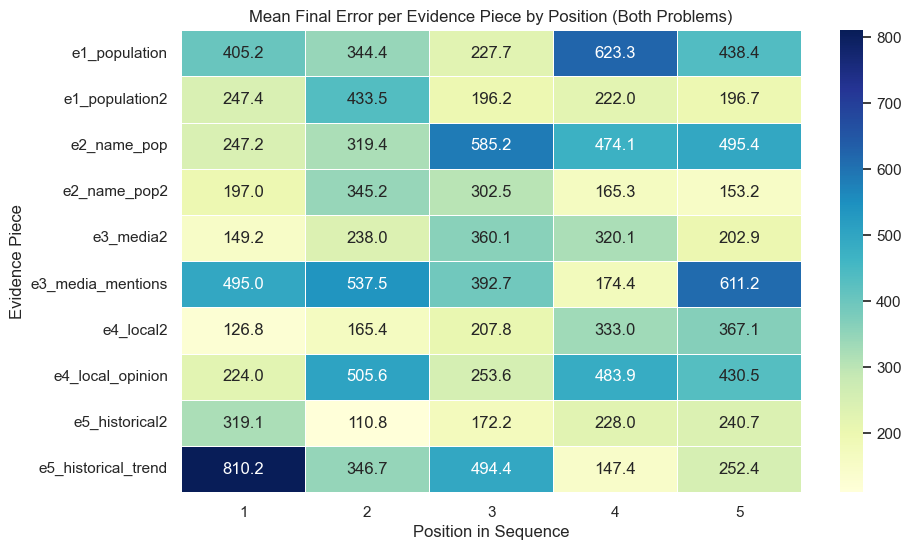

Problem 1 - Correlation of evidence position vs final error:
{'e1_population': np.float64(0.20133319694499957), 'e2_name_pop': np.float64(0.36649809530041794), 'e3_media_mentions': np.float64(-0.3014509732355433), 'e4_local_opinion': np.float64(0.17147077512832518), 'e5_historical_trend': np.float64(-0.5507063330427542)}

Problem 2 - Correlation of evidence position vs final error:
{'e1_population2': np.float64(-0.23277182960476037), 'e2_name_pop2': np.float64(-0.10080094193597591), 'e3_media2': np.float64(-0.005092227538845867), 'e4_local2': np.float64(0.5878273283730382), 'e5_historical2': np.float64(-0.22542195788031638)}


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# -----------------------------
# Setup: two new problems
# -----------------------------
participants = [f"P{i}" for i in range(1,21)]

# Problem 1
evidence_p1 = ["e1_population","e2_name_pop","e3_media_mentions","e4_local_opinion","e5_historical_trend"]
TRUE_P1 = 3000

# Problem 2
evidence_p2 = ["e1_population2","e2_name_pop2","e3_media2","e4_local2","e5_historical2"]
TRUE_P2 = 1500

# Effect strengths (how much each evidence moves guess towards truth)
effect_strengths_p1 = [0.5,0.3,0.1,0.0,-0.2]
effect_strengths_p2 = [0.6,0.4,0.2,0.1,-0.1]

# Initial guesses
initial_guess_p1 = np.random.randint(500,5000,size=20)
initial_guess_p2 = np.random.randint(500,5000,size=20)

# Random sequences for each participant
def random_sequences(evidence_list, n_participants):
    sequences = []
    for _ in range(n_participants):
        seq = np.random.permutation(evidence_list)
        sequences.append(seq)
    return sequences

seq_p1 = random_sequences(evidence_p1, 20)
seq_p2 = random_sequences(evidence_p2, 20)

# -----------------------------
# Simulate final guesses
# -----------------------------
def simulate_final_guesses(initial_guesses, sequences, strengths, evidence_list, true_value):
    final_guesses = []
    for i in range(len(initial_guesses)):
        guess = initial_guesses[i]
        for ev in sequences[i]:
            idx = evidence_list.index(ev)
            strength = strengths[idx]
            guess = guess + strength*(true_value - guess)
        final_guesses.append(guess)
    return final_guesses

final_guesses_p1 = simulate_final_guesses(initial_guess_p1, seq_p1, effect_strengths_p1, evidence_p1, TRUE_P1)
final_guesses_p2 = simulate_final_guesses(initial_guess_p2, seq_p2, effect_strengths_p2, evidence_p2, TRUE_P2)

# -----------------------------
# Build DataFrames
# -----------------------------
def build_df(initial_guesses, final_guesses, sequences, evidence_list, true_value):
    df = pd.DataFrame({"participant": participants,
                       "initial_guess": initial_guesses,
                       "final_guess": final_guesses})
    for step in range(5):
        df[f"Step_{step+1}"] = [sequences[i][step] for i in range(len(sequences))]
    df["error"] = abs(df["final_guess"] - true_value)
    return df

df_p1 = build_df(initial_guess_p1, final_guesses_p1, seq_p1, evidence_p1, TRUE_P1)
df_p2 = build_df(initial_guess_p2, final_guesses_p2, seq_p2, evidence_p2, TRUE_P2)

# -----------------------------
# Compute mean error per evidence position
# -----------------------------
def mean_error_by_position(df, evidence_list):
    evidence_cols = [f"Step_{i+1}" for i in range(5)]
    agg = []
    for e in evidence_list:
        for pos in range(1,6):
            mask = df[evidence_cols].apply(lambda row: list(row).index(e)+1==pos if e in row.values else False, axis=1)
            mean_err = df.loc[mask, "error"].mean()
            agg.append({"evidence": e, "position": pos, "mean_final_error": mean_err})
    return pd.DataFrame(agg)

agg_p1 = mean_error_by_position(df_p1, evidence_p1)
agg_p2 = mean_error_by_position(df_p2, evidence_p2)

# -----------------------------
# Combine for heatmap
# -----------------------------
agg_combined = pd.concat([agg_p1.assign(problem="Problem1"), agg_p2.assign(problem="Problem2")])
heatmap_df = agg_combined.pivot_table(index="evidence", columns="position", values="mean_final_error")

# -----------------------------
# Plot heatmap
# -----------------------------
plt.figure(figsize=(10,6))
sns.heatmap(heatmap_df, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.5)
plt.title("Mean Final Error per Evidence Piece by Position (Both Problems)")
plt.ylabel("Evidence Piece")
plt.xlabel("Position in Sequence")
plt.show()

# -----------------------------
# Correlation of evidence position vs final error
# -----------------------------
def evidence_position_correlation(df, evidence_list):
    evidence_cols = [f"Step_{i+1}" for i in range(5)]
    corrs = {}
    for e in evidence_list:
        positions = df[evidence_cols].apply(lambda row: list(row).index(e)+1 if e in row.values else np.nan, axis=1)
        corrs[e] = positions.corr(df["error"])
    return corrs

corrs_p1 = evidence_position_correlation(df_p1, evidence_p1)
corrs_p2 = evidence_position_correlation(df_p2, evidence_p2)

print("Problem 1 - Correlation of evidence position vs final error:")
print(corrs_p1)
print("\nProblem 2 - Correlation of evidence position vs final error:")
print(corrs_p2)

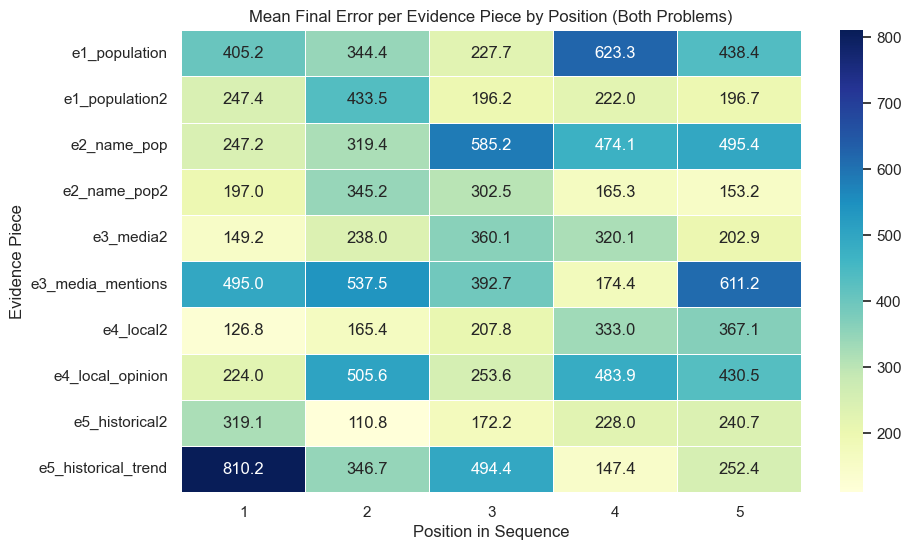


Mean Final Error Table (Evidence x Position):
position                 1      2      3      4      5
evidence                                              
e1_population        405.2  344.4  227.7  623.3  438.4
e1_population2       247.4  433.5  196.2  222.0  196.7
e2_name_pop          247.2  319.4  585.2  474.1  495.4
e2_name_pop2         197.0  345.2  302.5  165.3  153.2
e3_media2            149.2  238.0  360.1  320.1  202.9
e3_media_mentions    495.0  537.5  392.7  174.4  611.2
e4_local2            126.8  165.4  207.8  333.0  367.1
e4_local_opinion     224.0  505.6  253.6  483.9  430.5
e5_historical2       319.1  110.8  172.2  228.0  240.7
e5_historical_trend  810.2  346.7  494.4  147.4  252.4

Problem 1 - Correlation of evidence position vs final error:
{'e1_population': np.float64(0.20133319694499957), 'e2_name_pop': np.float64(0.36649809530041794), 'e3_media_mentions': np.float64(-0.3014509732355433), 'e4_local_opinion': np.float64(0.17147077512832518), 'e5_historical_trend': np

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# -----------------------------
# Setup: two new problems
# -----------------------------
participants = [f"P{i}" for i in range(1,21)]

# Problem 1
evidence_p1 = ["e1_population","e2_name_pop","e3_media_mentions","e4_local_opinion","e5_historical_trend"]
TRUE_P1 = 3000

# Problem 2
evidence_p2 = ["e1_population2","e2_name_pop2","e3_media2","e4_local2","e5_historical2"]
TRUE_P2 = 1500

# Effect strengths (how much each evidence moves guess towards truth)
effect_strengths_p1 = [0.5,0.3,0.1,0.0,-0.2]
effect_strengths_p2 = [0.6,0.4,0.2,0.1,-0.1]

# Initial guesses
initial_guess_p1 = np.random.randint(500,5000,size=20)
initial_guess_p2 = np.random.randint(500,5000,size=20)

# Random sequences for each participant
def random_sequences(evidence_list, n_participants):
    sequences = []
    for _ in range(n_participants):
        seq = np.random.permutation(evidence_list)
        sequences.append(seq)
    return sequences

seq_p1 = random_sequences(evidence_p1, 20)
seq_p2 = random_sequences(evidence_p2, 20)

# -----------------------------
# Simulate final guesses
# -----------------------------
def simulate_final_guesses(initial_guesses, sequences, strengths, evidence_list, true_value):
    final_guesses = []
    for i in range(len(initial_guesses)):
        guess = initial_guesses[i]
        for ev in sequences[i]:
            idx = evidence_list.index(ev)
            strength = strengths[idx]
            guess = guess + strength*(true_value - guess)
        final_guesses.append(guess)
    return final_guesses

final_guesses_p1 = simulate_final_guesses(initial_guess_p1, seq_p1, effect_strengths_p1, evidence_p1, TRUE_P1)
final_guesses_p2 = simulate_final_guesses(initial_guess_p2, seq_p2, effect_strengths_p2, evidence_p2, TRUE_P2)

# -----------------------------
# Build DataFrames
# -----------------------------
def build_df(initial_guesses, final_guesses, sequences, evidence_list, true_value):
    df = pd.DataFrame({"participant": participants,
                       "initial_guess": initial_guesses,
                       "final_guess": final_guesses})
    for step in range(5):
        df[f"Step_{step+1}"] = [sequences[i][step] for i in range(len(sequences))]
    df["error"] = abs(df["final_guess"] - true_value)
    return df

df_p1 = build_df(initial_guess_p1, final_guesses_p1, seq_p1, evidence_p1, TRUE_P1)
df_p2 = build_df(initial_guess_p2, final_guesses_p2, seq_p2, evidence_p2, TRUE_P2)

# -----------------------------
# Compute mean error per evidence position
# -----------------------------
def mean_error_by_position(df, evidence_list):
    evidence_cols = [f"Step_{i+1}" for i in range(5)]
    agg = []
    for e in evidence_list:
        for pos in range(1,6):
            mask = df[evidence_cols].apply(lambda row: list(row).index(e)+1==pos if e in row.values else False, axis=1)
            mean_err = df.loc[mask, "error"].mean()
            agg.append({"evidence": e, "position": pos, "mean_final_error": mean_err})
    return pd.DataFrame(agg)

agg_p1 = mean_error_by_position(df_p1, evidence_p1)
agg_p2 = mean_error_by_position(df_p2, evidence_p2)

# -----------------------------
# Combine for heatmap
# -----------------------------
agg_combined = pd.concat([agg_p1.assign(problem="Problem1"), agg_p2.assign(problem="Problem2")])
heatmap_df = agg_combined.pivot_table(index="evidence", columns="position", values="mean_final_error")

# -----------------------------
# Plot heatmap
# -----------------------------
plt.figure(figsize=(10,6))
sns.heatmap(heatmap_df, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.5)
plt.title("Mean Final Error per Evidence Piece by Position (Both Problems)")
plt.ylabel("Evidence Piece")
plt.xlabel("Position in Sequence")
plt.show()

# -----------------------------
# Text version of heatmap
# -----------------------------
print("\nMean Final Error Table (Evidence x Position):")
print(heatmap_df.round(1).to_string())

# -----------------------------
# Correlation of evidence position vs final error
# -----------------------------
def evidence_position_correlation(df, evidence_list):
    evidence_cols = [f"Step_{i+1}" for i in range(5)]
    corrs = {}
    for e in evidence_list:
        positions = df[evidence_cols].apply(lambda row: list(row).index(e)+1 if e in row.values else np.nan, axis=1)
        corrs[e] = positions.corr(df["error"])
    return corrs

corrs_p1 = evidence_position_correlation(df_p1, evidence_p1)
corrs_p2 = evidence_position_correlation(df_p2, evidence_p2)

print("\nProblem 1 - Correlation of evidence position vs final error:")
print(corrs_p1)
print("\nProblem 2 - Correlation of evidence position vs final error:")
print(corrs_p2)

In [21]:
# -----------------------------
# Function to get optimal sequence
# -----------------------------
def optimal_sequence_from_heatmap(heatmap_df):
    """
    Takes a DataFrame where rows are evidence pieces, columns are positions,
    and values are mean final error. Returns the sequence of evidence that
    minimizes final error.
    """
    optimal_positions = heatmap_df.idxmin(axis=1)  # column (position) with lowest error per evidence
    # Sort evidence pieces by their optimal position (lowest first)
    sorted_evidence = optimal_positions.sort_values().index.tolist()
    # For clarity, also show which position each should ideally be
    positions_dict = {e: optimal_positions[e] for e in sorted_evidence}
    return sorted_evidence, positions_dict

# -----------------------------
# Run for Problem 1
# -----------------------------
heatmap_p1 = heatmap_df.loc[evidence_p1]  # only Problem 1 rows
seq_p1, pos_p1 = optimal_sequence_from_heatmap(heatmap_p1)
print("\nProblem 1 - Optimal Evidence Sequence:")
print(seq_p1)
print("Optimal positions per evidence piece:", pos_p1)

# -----------------------------
# Run for Problem 2
# -----------------------------
heatmap_p2 = heatmap_df.loc[evidence_p2]  # only Problem 2 rows
seq_p2, pos_p2 = optimal_sequence_from_heatmap(heatmap_p2)
print("\nProblem 2 - Optimal Evidence Sequence:")
print(seq_p2)
print("Optimal positions per evidence piece:", pos_p2)


Problem 1 - Optimal Evidence Sequence:
['e2_name_pop', 'e4_local_opinion', 'e1_population', 'e3_media_mentions', 'e5_historical_trend']
Optimal positions per evidence piece: {'e2_name_pop': np.int64(1), 'e4_local_opinion': np.int64(1), 'e1_population': np.int64(3), 'e3_media_mentions': np.int64(4), 'e5_historical_trend': np.int64(4)}

Problem 2 - Optimal Evidence Sequence:
['e4_local2', 'e3_media2', 'e5_historical2', 'e1_population2', 'e2_name_pop2']
Optimal positions per evidence piece: {'e4_local2': np.int64(1), 'e3_media2': np.int64(1), 'e5_historical2': np.int64(2), 'e1_population2': np.int64(3), 'e2_name_pop2': np.int64(5)}


In [22]:
# -----------------------------
# STEP-BY-STEP IMPROVEMENT + TOP 3 EVIDENCE
# -----------------------------

def compute_step_improvements(df, evidence_list, strengths, true_value):
    evidence_cols = [f"Step_{i+1}" for i in range(5)]
    
    records = []
    
    for _, row in df.iterrows():
        guess = row["initial_guess"]
        prev_error = abs(guess - true_value)
        
        for step_idx, col in enumerate(evidence_cols):
            ev = row[col]
            strength = strengths[evidence_list.index(ev)]
            
            # update guess
            guess = guess + strength * (true_value - guess)
            new_error = abs(guess - true_value)
            
            improvement = prev_error - new_error
            
            records.append({
                "participant": row["participant"],
                "evidence": ev,
                "step": step_idx + 1,
                "improvement": improvement
            })
            
            prev_error = new_error
    
    return pd.DataFrame(records)


def best_three_evidence(df, evidence_list, strengths, true_value):
    step_df = compute_step_improvements(df, evidence_list, strengths, true_value)
    
    summary = (
        step_df
        .groupby("evidence")["improvement"]
        .mean()
        .sort_values(ascending=False)
    )
    
    top3 = summary.head(3)
    
    print("\nAverage improvement per evidence:")
    print(summary)
    
    print("\nTop 3 evidence pieces (most useful):")
    print(top3)
    
    return summary, top3


# -----------------------------
# RUN FOR BOTH PROBLEMS
# -----------------------------
print("\n===== PROBLEM 1 =====")
summary_p1, top3_p1 = best_three_evidence(
    df_p1, evidence_p1, effect_strengths_p1, TRUE_P1
)

print("\n===== PROBLEM 2 =====")
summary_p2, top3_p2 = best_three_evidence(
    df_p2, evidence_p2, effect_strengths_p2, TRUE_P2
)


===== PROBLEM 1 =====

Average improvement per evidence:
evidence
e1_population          499.44690
e2_name_pop            252.87615
e3_media_mentions      100.30885
e4_local_opinion         0.00000
e5_historical_trend   -158.66650
Name: improvement, dtype: float64

Top 3 evidence pieces (most useful):
evidence
e1_population        499.44690
e2_name_pop          252.87615
e3_media_mentions    100.30885
Name: improvement, dtype: float64

===== PROBLEM 2 =====

Average improvement per evidence:
evidence
e1_population2    534.816840
e2_name_pop2      364.070776
e3_media2         126.760708
e4_local2          59.588980
e5_historical2    -81.867912
Name: improvement, dtype: float64

Top 3 evidence pieces (most useful):
evidence
e1_population2    534.816840
e2_name_pop2      364.070776
e3_media2         126.760708
Name: improvement, dtype: float64


In [23]:
import itertools
import pandas as pd
import numpy as np
import time

# -----------------------------
# Value function: simulate final error
# -----------------------------
def value_function(sequence, initial_guesses, evidence_list, strengths, true_value):
    errors = []
    for guess in initial_guesses:
        for ev in sequence:
            idx = evidence_list.index(ev)
            strength = strengths[idx]
            guess = guess + strength * (true_value - guess)
        errors.append(abs(guess - true_value))
    return -np.mean(errors)  # negative error = higher is better


# -----------------------------
# APPROXIMATE SHAPLEY (sampling permutations)
# -----------------------------
def shapley_approx(evidence_list, initial_guesses, strengths, true_value, n_samples=200):
    shapley = {e: 0 for e in evidence_list}
    
    for _ in range(n_samples):
        perm = np.random.permutation(evidence_list)
        
        current_set = []
        current_value = value_function(current_set, initial_guesses, evidence_list, strengths, true_value)
        
        for ev in perm:
            new_set = current_set + [ev]
            new_value = value_function(new_set, initial_guesses, evidence_list, strengths, true_value)
            
            marginal_contribution = new_value - current_value
            shapley[ev] += marginal_contribution
            
            current_set = new_set
            current_value = new_value
    
    # average
    for e in shapley:
        shapley[e] /= n_samples
    
    return dict(sorted(shapley.items(), key=lambda x: x[1], reverse=True))


# -----------------------------
# EXACT SHAPLEY (all permutations)
# -----------------------------
def shapley_exact(evidence_list, initial_guesses, strengths, true_value):
    shapley = {e: 0 for e in evidence_list}
    perms = list(itertools.permutations(evidence_list))
    
    for perm in perms:
        current_set = []
        current_value = value_function(current_set, initial_guesses, evidence_list, strengths, true_value)
        
        for ev in perm:
            new_set = current_set + [ev]
            new_value = value_function(new_set, initial_guesses, evidence_list, strengths, true_value)
            
            marginal_contribution = new_value - current_value
            shapley[ev] += marginal_contribution
            
            current_set = new_set
            current_value = new_value
    
    # normalize
    n_perms = len(perms)
    for e in shapley:
        shapley[e] /= n_perms
    
    return dict(sorted(shapley.items(), key=lambda x: x[1], reverse=True))


# -----------------------------
# RUN FOR BOTH PROBLEMS
# -----------------------------
def run_shapley_analysis(evidence_list, initial_guesses, strengths, true_value, label):
    print(f"\n===== {label} =====")
    
    # Approximate
    start = time.time()
    approx = shapley_approx(evidence_list, initial_guesses, strengths, true_value, n_samples=200)
    end = time.time()
    print("\nApproximate Shapley:")
    print(approx)
    print(f"Time: {round(end-start,2)} seconds")
    
    # Exact
    start = time.time()
    exact = shapley_exact(evidence_list, initial_guesses, strengths, true_value)
    end = time.time()
    print("\nExact Shapley:")
    print(exact)
    print(f"Time: {round(end-start,2)} seconds")
    
    return approx, exact


# -----------------------------
# RUN (uses your existing variables)
# -----------------------------
approx_p1, exact_p1 = run_shapley_analysis(
    evidence_p1, initial_guess_p1, effect_strengths_p1, TRUE_P1, "Problem 1"
)

approx_p2, exact_p2 = run_shapley_analysis(
    evidence_p2, initial_guess_p2, effect_strengths_p2, TRUE_P2, "Problem 2"
)


===== Problem 1 =====

Approximate Shapley:
{'e1_population': np.float64(482.7745470000001), 'e2_name_pop': np.float64(266.52957299999986), 'e3_media_mentions': np.float64(79.47688949999987), 'e4_local_opinion': np.float64(0.0), 'e5_historical_trend': np.float64(-134.81560949999974)}
Time: 0.34 seconds

Exact Shapley:
{'e1_population': np.float64(493.6042750000004), 'e2_name_pop': np.float64(260.7948749999996), 'e3_media_mentions': np.float64(78.56387499999995), 'e4_local_opinion': np.float64(0.0), 'e5_historical_trend': np.float64(-138.99762499999983)}
Time: 0.16 seconds

===== Problem 2 =====

Approximate Shapley:
{'e1_population2': np.float64(538.1014350600007), 'e2_name_pop2': np.float64(318.75015852000035), 'e3_media2': np.float64(138.03167592000003), 'e4_local2': np.float64(73.44844326000002), 'e5_historical2': np.float64(-64.96232076000003)}
Time: 0.31 seconds

Exact Shapley:
{'e1_population2': np.float64(538.6569354000002), 'e2_name_pop2': np.float64(316.36595040000003), 'e3_m